In [5]:
import os
import sys
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, ConcatDataset
from torchvision import transforms, models
from PIL import Image
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings
import pandas as pd
import pickle
import copy
import joblib
warnings.filterwarnings('ignore')

def check_gpu_available():
    if not torch.cuda.is_available():
        print("Error: No available GPU device detected.")
        print("Please ensure:")
        print("1. CUDA and cuDNN are installed")
        print("2. GPU-enabled PyTorch version is installed")
        print("3. Graphics card driver is up to date")
        print("\nProgram requires GPU for training, exiting now...")
        sys.exit(1)

    print(f"✓ GPU available: {torch.cuda.get_device_name(0)}")
    print(f"  Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    print(f"  CUDA version: {torch.version.cuda}")
    return True

check_gpu_available()

def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

class CustomDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform
        
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert('RGB')
        label = self.labels[idx]
        
        if self.transform:
            image = self.transform(image)
            
        return image, label

class ParallelResNet18(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        base = models.resnet18(pretrained=True)
        num_ftrs = base.fc.in_features
        base.fc = nn.Identity()
        self.branch1 = copy.deepcopy(base)
        self.branch2 = copy.deepcopy(base)
        self.fc = nn.Linear(num_ftrs * 2, num_classes)

    def forward(self, x):
        f1 = self.branch1(x)
        f2 = self.branch2(x)
        feats = torch.cat([f1, f2], dim=1)
        out = self.fc(feats)
        return out

def load_data(immature_dir, mature_dir):
    immature_paths = []
    mature_paths = []
    
    for img_name in os.listdir(immature_dir):
        if img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
            immature_paths.append(os.path.join(immature_dir, img_name))
    
    for img_name in os.listdir(mature_dir):
        if img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
            mature_paths.append(os.path.join(mature_dir, img_name))
    
    all_paths = immature_paths + mature_paths
    all_labels = [0] * len(immature_paths) + [1] * len(mature_paths)
    
    print(f"Immature images: {len(immature_paths)}")
    print(f"Mature images: {len(mature_paths)}")
    print(f"Total images: {len(all_paths)}")
    
    return all_paths, all_labels

def get_transforms():
    train_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(10),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                           std=[0.229, 0.224, 0.225])
    ])
    
    test_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                           std=[0.229, 0.224, 0.225])
    ])
    
    return train_transform, test_transform

def create_parallel_resnet18_model(num_classes=2):
    model = ParallelResNet18(num_classes=num_classes)
    return model

def calculate_metrics(all_labels, all_predictions):
    accuracy = np.mean(np.array(all_labels) == np.array(all_predictions))
    
    precision = precision_score(all_labels, all_predictions, average='weighted')
    recall = recall_score(all_labels, all_predictions, average='weighted')
    f1 = f1_score(all_labels, all_predictions, average='weighted')
    
    precision_per_class = precision_score(all_labels, all_predictions, average=None)
    recall_per_class = recall_score(all_labels, all_predictions, average=None)
    f1_per_class = f1_score(all_labels, all_predictions, average=None)
    
    cm = confusion_matrix(all_labels, all_predictions)
    
    report = classification_report(all_labels, all_predictions, 
                                  target_names=['immature', 'mature'], 
                                  output_dict=True)
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'precision_per_class': precision_per_class,
        'recall_per_class': recall_per_class,
        'f1_per_class': f1_per_class,
        'confusion_matrix': cm,
        'classification_report': report
    }

def train_epoch(model, dataloader, criterion, optimizer, device, ewc=None, ewc_lambda=1e-3):
    model.train()
    running_loss = 0.0
    all_predictions = []
    all_labels = []
    
    progress_bar = tqdm(dataloader, desc='Training')
    for images, labels in progress_bar:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        if ewc is not None:
            ewc_loss = ewc.penalty(model)
            loss += ewc_lambda * ewc_loss
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        
        all_predictions.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        
        batch_acc = (predicted == labels).sum().item() / labels.size(0)
        progress_bar.set_postfix({'Loss': running_loss/len(dataloader), 'Acc': batch_acc})
    
    epoch_loss = running_loss / len(dataloader)
    
    metrics = calculate_metrics(all_labels, all_predictions)
    metrics['loss'] = epoch_loss
    
    return epoch_loss, metrics

def evaluate_model(model, dataloader, criterion, device, dataset_name="Dataset"):
    model.eval()
    running_loss = 0.0
    all_predictions = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            
            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    epoch_loss = running_loss / len(dataloader)
    
    metrics = calculate_metrics(all_labels, all_predictions)
    metrics['loss'] = epoch_loss
    
    return epoch_loss, metrics

def print_detailed_metrics(metrics, dataset_name="Dataset"):
    print(f"\n{dataset_name} Detailed Metrics:")
    print("-" * 50)
    print(f"Loss: {metrics['loss']:.4f}")
    print(f"Accuracy: {metrics['accuracy']:.4f}")
    print(f"Precision: {metrics['precision']:.4f}")
    print(f"Recall: {metrics['recall']:.4f}")
    print(f"F1-Score: {metrics['f1']:.4f}")
    
    print(f"\nPer-class Metrics:")
    print(f"  Immature (0): Precision={metrics['precision_per_class'][0]:.4f}, "
          f"Recall={metrics['recall_per_class'][0]:.4f}, F1={metrics['f1_per_class'][0]:.4f}")
    print(f"  Mature (1): Precision={metrics['precision_per_class'][1]:.4f}, "
          f"Recall={metrics['recall_per_class'][1]:.4f}, F1={metrics['f1_per_class'][1]:.4f}")
    
    print(f"\nConfusion Matrix:")
    print(metrics['confusion_matrix'])

class EWC:
    def __init__(self, model, dataloader, device):
        self.model = model
        self.dataloader = dataloader
        self.device = device
        self.params = {n: p.clone().detach() for n, p in model.named_parameters() if p.requires_grad}
        self.fisher = self._compute_fisher()
    
    def _compute_fisher(self):
        fisher = {}
        for n, p in self.model.named_parameters():
            if p.requires_grad:
                fisher[n] = torch.zeros_like(p)
        
        self.model.eval()
        criterion = nn.CrossEntropyLoss()
        
        for images, labels in self.dataloader:
            images, labels = images.to(self.device), labels.to(self.device)
            self.model.zero_grad()
            outputs = self.model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            
            for n, p in self.model.named_parameters():
                if p.requires_grad:
                    fisher[n] += p.grad.data ** 2 / len(self.dataloader)
        
        return fisher
    
    def penalty(self, model):
        loss = 0
        for n, p in model.named_parameters():
            if p.requires_grad:
                loss += (self.fisher[n] * (p - self.params[n]) ** 2).sum()
        return loss

def train_parallel_resnet18(train_mode=True):    
    if not train_mode and os.path.exists('parallel_resnet18_complete.pth'):
        print("Loading saved Parallel ResNet18 model...")
        try:
            checkpoint = torch.load('parallel_resnet18_complete.pth', 
                                  map_location='cuda' if torch.cuda.is_available() else 'cpu')
            
            model = create_parallel_resnet18_model(num_classes=2)
            model.load_state_dict(checkpoint['model_state_dict'])
            
            data_info = checkpoint['data_info']
            results_info = checkpoint['results_info']
            
            device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
            model = model.to(device)
            model.eval()
            
            print("✓ Parallel ResNet18 model loaded successfully!")
            
            return {
                'model': model,
                'data_info': data_info,
                'results_info': results_info,
                'device': device
            }
            
        except Exception as e:
            print(f"Error loading model: {e}")
            print("Switching to training mode...")
            train_mode = True
    
    print("Starting training of Parallel ResNet18 model...")
    
    immature_dir = r"E:\TSG\jupyterlab\machine learning image\augmented_dataset\immature"
    mature_dir = r"E:\TSG\jupyterlab\machine learning image\augmented_dataset\mature"
    
    print("Loading data...")
    all_paths, all_labels = load_data(immature_dir, mature_dir)
    
    print("\nSplitting data into train and test sets...")
    train_paths, test_paths, train_labels, test_labels = train_test_split(
        all_paths, all_labels, test_size=0.2, random_state=42, stratify=all_labels
    )
    
    print(f"Train size: {len(train_paths)}")
    print(f"Test size: {len(test_paths)}")
    
    train_transform, test_transform = get_transforms()
    
    train_dataset = CustomDataset(train_paths, train_labels, train_transform)
    test_dataset = CustomDataset(test_paths, test_labels, test_transform)
    
    device = torch.device("cuda")
    print(f"\nUsing device: {device}")
    
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
    
    model = create_parallel_resnet18_model(num_classes=2)
    model = model.to(device)
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.1)
    
    num_epochs = 60
    best_train_acc = 0
    best_model_state = None
    best_train_metrics = None
    best_train_loss = None
    
    print(f"\nStarting training for {num_epochs} epochs...")
    print("="*60)
    
    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        
        train_loss, train_metrics = train_epoch(model, train_loader, criterion, optimizer, device)
        
        scheduler.step()
        
        print(f"Training Set - Loss: {train_loss:.4f}, Acc: {train_metrics['accuracy']:.4f}, "
              f"F1: {train_metrics['f1']:.4f}")
        
        if train_metrics['accuracy'] > best_train_acc:
            best_train_acc = train_metrics['accuracy']
            best_model_state = model.state_dict().copy()
            best_train_metrics = train_metrics
            best_train_loss = train_loss
    
    print("\n" + "="*60)
    print("Best Training Set Detailed Metrics:")
    print("="*60)
    print_detailed_metrics(best_train_metrics, "Training Set")
    
    print("\n" + "="*60)
    print("Evaluating best model on test set...")
    print("="*60)
    
    model.load_state_dict(best_model_state)
    test_loss, test_metrics = evaluate_model(model, test_loader, criterion, device, "Test Set")
    
    print("\n" + "="*60)
    print("Test Set Detailed Metrics:")
    print("="*60)
    print_detailed_metrics(test_metrics, "Test Set")
    
    def export_results_to_excel(train_results, test_results, filename='parallel_resnet_training_results.xlsx'):
        all_results = []
        
        train_data = {
            'Dataset': 'Train',
            'Loss': train_results['loss'],
            'Accuracy': train_results['accuracy'],
            'Precision': train_results['precision'],
            'Recall': train_results['recall'],
            'F1_Score': train_results['f1'],
            'Precision_Class0': train_results['precision_per_class'][0],
            'Precision_Class1': train_results['precision_per_class'][1],
            'Recall_Class0': train_results['recall_per_class'][0],
            'Recall_Class1': train_results['recall_per_class'][1],
            'F1_Class0': train_results['f1_per_class'][0],
            'F1_Class1': train_results['f1_per_class'][1]
        }
        all_results.append(train_data)
        
        test_data = {
            'Dataset': 'Test',
            'Loss': test_results['loss'],
            'Accuracy': test_results['accuracy'],
            'Precision': test_results['precision'],
            'Recall': test_results['recall'],
            'F1_Score': test_results['f1'],
            'Precision_Class0': test_results['precision_per_class'][0],
            'Precision_Class1': test_results['precision_per_class'][1],
            'Recall_Class0': test_results['recall_per_class'][0],
            'Recall_Class1': test_results['recall_per_class'][1],
            'F1_Class0': test_results['f1_per_class'][0],
            'F1_Class1': test_results['f1_per_class'][1]
        }
        all_results.append(test_data)
        
        df = pd.DataFrame(all_results)
        
        df.to_excel(filename, index=False)
        print(f"\n✓ Results saved to {filename}")
        
        return df
    
    export_results_to_excel(best_train_metrics, test_metrics, 
                           'parallel_resnet_training_results.xlsx')
    
    print("\n" + "="*60)
    print("Saving model and all related information...")
    print("="*60)
    
    data_info = {
        'train_paths': train_paths,
        'test_paths': test_paths,
        'train_labels': train_labels,
        'test_labels': test_labels,
        'train_transform': train_transform,
        'test_transform': test_transform,
        'class_names': ['immature', 'mature'],
        'normalization_mean': [0.485, 0.456, 0.406],
        'normalization_std': [0.229, 0.224, 0.225],
        'version': 1
    }
    
    results_info = {
        'best_train_metrics': best_train_metrics,
        'test_metrics': test_metrics,
        'best_model_state': best_model_state
    }
    
    torch.save({
        'model_state_dict': best_model_state,
        'model_class': 'ParallelResNet18',
        'num_classes': 2,
        'data_info': data_info,
        'results_info': results_info,
        'device': str(device)
    }, 'parallel_resnet18_complete.pth')
    
    print("✓ Model and data saved to: parallel_resnet18_complete.pth")
    
    torch.save(best_model_state, 'best_parallel_resnet18_model.pth')
    print("✓ Best model weights saved to: best_parallel_resnet18_model.pth")
    
    joblib.dump(data_info, 'parallel_resnet18_data_info.pkl')
    print("✓ Data info saved to: parallel_resnet18_data_info.pkl")
    
    joblib.dump(results_info, 'parallel_resnet18_results_info.pkl')
    print("✓ Results info saved to: parallel_resnet18_results_info.pkl")
    
    print("\n" + "="*60)
    print("Parallel ResNet18 model training completed!")
    print("="*60)
    
    return {
        'model': model,
        'data_info': data_info,
        'results_info': results_info,
        'device': device
    }

def incremental_train_parallel_resnet18(
    new_immature_dir=r"E:\TSG\jupyterlab\machine learning image\TL SOFMaugmented_data\augmented_immature",
    new_mature_dir=r"E:\TSG\jupyterlab\machine learning image\TL SOFMaugmented_data\augmented_mature",
    num_epochs=20,
    lr=0.0005,
    ewc_lambda=1e-3,
    use_ewc=True
):
    print("="*60)
    print("Parallel ResNet18 Incremental Learning")
    print("="*60)
    
    if not os.path.exists('parallel_resnet18_complete.pth'):
        print("Error: No existing model found. Please run initial training first.")
        return None
    
    print("Loading existing model and data...")
    checkpoint = torch.load('parallel_resnet18_complete.pth', 
                          map_location='cuda' if torch.cuda.is_available() else 'cpu')
    
    model = create_parallel_resnet18_model(num_classes=2)
    model.load_state_dict(checkpoint['model_state_dict'])
    
    old_data_info = checkpoint['data_info']
    old_results_info = checkpoint['results_info']
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    
    print(f"✓ Existing model loaded (Version: {old_data_info.get('version', 1)})")
    
    print("\nLoading new incremental data...")
    new_paths, new_labels = load_data(new_immature_dir, new_mature_dir)
    
    if len(new_paths) == 0:
        print("Error: No new images found in the specified directories.")
        return None
    
    print("\nMerging old and new data...")
    old_train_paths = old_data_info['train_paths']
    old_train_labels = old_data_info['train_labels']
    old_test_paths = old_data_info['test_paths']
    old_test_labels = old_data_info['test_labels']
    
    _, ewc_paths, _, ewc_labels = train_test_split(
        old_train_paths, old_train_labels, test_size=0.2, 
        random_state=42, stratify=old_train_labels
    )
    
    new_train_paths, new_test_paths, new_train_labels, new_test_labels = train_test_split(
        new_paths, new_labels, test_size=0.2, random_state=42, stratify=new_labels
    )
    
    combined_train_paths = old_train_paths + new_train_paths
    combined_train_labels = old_train_labels + new_train_labels
    
    combined_test_paths = old_test_paths + new_test_paths
    combined_test_labels = old_test_labels + new_test_labels
    
    print(f"Combined train size: {len(combined_train_paths)}")
    print(f"Combined test size: {len(combined_test_paths)}")
    print(f"EWC validation size: {len(ewc_paths)}")
    
    train_transform = old_data_info['train_transform']
    test_transform = old_data_info['test_transform']
    
    train_dataset = CustomDataset(combined_train_paths, combined_train_labels, train_transform)
    test_dataset = CustomDataset(combined_test_paths, combined_test_labels, test_transform)
    ewc_dataset = CustomDataset(ewc_paths, ewc_labels, test_transform)
    
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
    ewc_loader = DataLoader(ewc_dataset, batch_size=32, shuffle=False)
    
    ewc = None
    if use_ewc:
        print("\nComputing EWC fisher information matrix...")
        ewc = EWC(model, ewc_loader, device)
        print("✓ EWC matrix computed")
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
    
    best_test_acc = 0
    best_model_state = None
    best_test_metrics = None
    
    print(f"\nStarting incremental training for {num_epochs} epochs...")
    print("="*60)
    
    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        
        train_loss, train_metrics = train_epoch(
            model, train_loader, criterion, optimizer, device, 
            ewc=ewc, ewc_lambda=ewc_lambda
        )
        
        scheduler.step()
        
        print(f"Training Set - Loss: {train_loss:.4f}, Acc: {train_metrics['accuracy']:.4f}, "
              f"F1: {train_metrics['f1']:.4f}")
        
        test_loss, test_metrics = evaluate_model(model, test_loader, criterion, device, "Test Set")
        print(f"Test Set - Loss: {test_loss:.4f}, Acc: {test_metrics['accuracy']:.4f}, "
              f"F1: {test_metrics['f1']:.4f}")
        
        if test_metrics['accuracy'] > best_test_acc:
            best_test_acc = test_metrics['accuracy']
            best_model_state = model.state_dict().copy()
            best_test_metrics = test_metrics
    
    print("\n" + "="*60)
    print("Incremental Training Complete!")
    print("="*60)
    
    print("\nBest Test Set Metrics:")
    print_detailed_metrics(best_test_metrics, "Combined Test Set")
    
    print("\n" + "="*60)
    print("Evaluating on new data only...")
    new_test_dataset = CustomDataset(new_test_paths, new_test_labels, test_transform)
    new_test_loader = DataLoader(new_test_dataset, batch_size=32, shuffle=False)
    new_test_loss, new_test_metrics = evaluate_model(model, new_test_loader, criterion, device, "New Test Set")
    print_detailed_metrics(new_test_metrics, "New Test Set")
    
    new_version = old_data_info.get('version', 1) + 1
    updated_data_info = {
        'train_paths': combined_train_paths,
        'test_paths': combined_test_paths,
        'train_labels': combined_train_labels,
        'test_labels': combined_test_labels,
        'train_transform': train_transform,
        'test_transform': test_transform,
        'class_names': ['immature', 'mature'],
        'normalization_mean': old_data_info['normalization_mean'],
        'normalization_std': old_data_info['normalization_std'],
        'version': new_version,
        'incremental_update': True,
        'last_update': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')
    }
    
    updated_results_info = {
        'best_train_metrics': train_metrics,
        'test_metrics': best_test_metrics,
        'new_data_metrics': new_test_metrics,
        'best_model_state': best_model_state
    }
    
    print("\n" + "="*60)
    print("Saving updated model...")
    print("="*60)
    
    if os.path.exists('parallel_resnet18_complete.pth'):
        os.rename('parallel_resnet18_complete.pth', 
                 f'parallel_resnet18_complete_v{old_data_info.get("version", 1)}.pth')
        print(f"✓ Old model backed up as parallel_resnet18_complete_v{old_data_info.get('version', 1)}.pth")
    
    torch.save({
        'model_state_dict': best_model_state,
        'model_class': 'ParallelResNet18',
        'num_classes': 2,
        'data_info': updated_data_info,
        'results_info': updated_results_info,
        'device': str(device)
    }, 'parallel_resnet18_complete.pth')
    
    print("✓ Updated model saved to: parallel_resnet18_complete.pth")
    
    torch.save(best_model_state, 'best_parallel_resnet18_model.pth')
    print("✓ Updated best model weights saved")
    
    joblib.dump(updated_data_info, 'parallel_resnet18_data_info.pkl')
    print("✓ Updated data info saved")
    
    joblib.dump(updated_results_info, 'parallel_resnet18_results_info.pkl')
    print("✓ Updated results info saved")
    
    print(f"\n✓ Model successfully updated to version {new_version}")
    
    return {
        'model': model,
        'data_info': updated_data_info,
        'results_info': updated_results_info,
        'device': device
    }

if __name__ == "__main__":
    if os.path.exists('parallel_resnet18_complete.pth'):
        print("Saved Parallel ResNet18 model detected.")
        print("Choose an option:")
        print("1. Load existing model")
        print("2. Retrain from scratch")
        print("3. Perform incremental learning with new data")
        
        choice = input("Enter your choice (1/2/3): ").strip()
        
        if choice == '1':
            resnet_results = train_parallel_resnet18(train_mode=False)
        elif choice == '2':
            resnet_results = train_parallel_resnet18(train_mode=True)
        elif choice == '3':
            resnet_results = incremental_train_parallel_resnet18()
        else:
            print("Invalid choice, loading existing model...")
            resnet_results = train_parallel_resnet18(train_mode=False)
    else:
        print("No existing model found. Starting initial training...")
        resnet_results = train_parallel_resnet18(train_mode=True)

✓ GPU available: NVIDIA GeForce RTX 5070 Ti
  Memory: 17.09 GB
  CUDA version: 11.8
Saved Parallel ResNet18 model detected.
Choose an option:
1. Load existing model
2. Retrain from scratch
3. Perform incremental learning with new data


Enter your choice (1/2/3):  3


Parallel ResNet18 Incremental Learning
Loading existing model and data...
✓ Existing model loaded (Version: 1)

Loading new incremental data...
Immature images: 1780
Mature images: 1060
Total images: 2840

Merging old and new data...
Combined train size: 5664
Combined test size: 1416
EWC validation size: 679

Computing EWC fisher information matrix...
✓ EWC matrix computed

Starting incremental training for 20 epochs...

Epoch 1/20


Training: 100%|███████████████████████████████████████████████| 177/177 [10:09<00:00,  3.44s/it, Loss=0.346, Acc=0.969]


Training Set - Loss: 0.3460, Acc: 0.8611, F1: 0.8599
Test Set - Loss: 0.2567, Acc: 0.8962, F1: 0.8950

Epoch 2/20


...

Training Set - Loss: 0.1086, Acc: 0.9582, F1: 0.9581
Test Set - Loss: 0.1536, Acc: 0.9421, F1: 0.9418

Epoch 19/20


Training: 100%|██████████████████████████████████████████████████| 177/177 [09:50<00:00,  3.34s/it, Loss=0.0997, Acc=1]


Training Set - Loss: 0.0997, Acc: 0.9620, F1: 0.9620
Test Set - Loss: 0.1452, Acc: 0.9386, F1: 0.9381

Epoch 20/20


Training: 100%|█████████████████████████████████████████████████████| 177/177 [09:49<00:00,  3.33s/it, Loss=0.1, Acc=1]


Training Set - Loss: 0.1003, Acc: 0.9620, F1: 0.9620
Test Set - Loss: 0.1441, Acc: 0.9449, F1: 0.9449

Incremental Training Complete!

Best Test Set Metrics:

Combined Test Set Detailed Metrics:
--------------------------------------------------
Loss: 0.1441
Accuracy: 0.9449
Precision: 0.9449
Recall: 0.9449
F1-Score: 0.9449

Per-class Metrics:
  Immature (0): Precision=0.9581, Recall=0.9601, F1=0.9591
  Mature (1): Precision=0.9177, Recall=0.9138, F1=0.9158

Confusion Matrix:
[[914  38]
 [ 40 424]]

Evaluating on new data only...

New Test Set Detailed Metrics:
--------------------------------------------------
Loss: 0.0782
Accuracy: 0.9718
Precision: 0.9719
Recall: 0.9718
F1-Score: 0.9717

Per-class Metrics:
  Immature (0): Precision=0.9696, Recall=0.9860, F1=0.9777
  Mature (1): Precision=0.9757, Recall=0.9481, F1=0.9617

Confusion Matrix:
[[351   5]
 [ 11 201]]

Saving updated model...
✓ Old model backed up as parallel_resnet18_complete_v1.pth
✓ Updated model saved to: parallel_resn

In [6]:
import os
import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import DataLoader, Dataset
from PIL import Image
from tqdm import tqdm
import joblib
import copy
from torchvision import transforms, models

class CustomDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform
        
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert('RGB')
        label = self.labels[idx]
        
        if self.transform:
            image = self.transform(image)
            
        return image, label

class ParallelResNet18(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        base = models.resnet18(pretrained=True)
        num_ftrs = base.fc.in_features
        base.fc = nn.Identity()
        self.branch1 = copy.deepcopy(base)
        self.branch2 = copy.deepcopy(base)
        self.fc = nn.Linear(num_ftrs * 2, num_classes)

    def forward(self, x):
        f1 = self.branch1(x)
        f2 = self.branch2(x)
        feats = torch.cat([f1, f2], dim=1)
        out = self.fc(feats)
        return out

def create_parallel_resnet18_model(num_classes=2):
    model = ParallelResNet18(num_classes=num_classes)
    return model

def extract_features_from_model(model, dataloader, device):
    model.eval()
    all_features = []
    all_labels = []
    
    with torch.no_grad():
        progress_bar = tqdm(dataloader, desc='Extracting Features')
        for images, labels in progress_bar:
            images = images.to(device)
            
            f1 = model.branch1(images)
            f2 = model.branch2(images)
            features = torch.cat([f1, f2], dim=1)
            
            all_features.extend(features.cpu().numpy())
            all_labels.extend(labels.numpy())
    
    return np.array(all_features), np.array(all_labels)

def extract_and_save_features(train_mode=True):    
    if not train_mode and os.path.exists('extracted_features_complete.pkl'):
        print("Loading saved features...")
        try:
            features_data = joblib.load('extracted_features_complete.pkl')
            
            print("✓ Features loaded successfully!")
            print(f"Train features shape: {features_data['train_features'].shape}")
            print(f"Test features shape: {features_data['test_features'].shape}")
            
            return features_data
            
        except Exception as e:
            print(f"Error loading features: {e}")
            print("Extracting features again...")
            train_mode = True
    
    print("Starting feature extraction...")
    
    if not os.path.exists('parallel_resnet18_complete.pth'):
        print("Error: Model file saved from Part A not found")
        print("Please run Part A to train the model first")
        return None
    
    print("Loading Parallel ResNet18 model and data...")
    
    checkpoint = torch.load('parallel_resnet18_complete.pth', 
                          map_location='cuda' if torch.cuda.is_available() else 'cpu')
    
    model = create_parallel_resnet18_model(num_classes=2)
    model.load_state_dict(checkpoint['model_state_dict'])
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    model.eval()
    
    data_info = checkpoint['data_info']
    train_paths = data_info['train_paths']
    test_paths = data_info['test_paths']
    train_labels = data_info['train_labels']
    test_labels = data_info['test_labels']
    test_transform = data_info['test_transform']
    
    print("✓ Model and data loaded successfully")
    
    print("\nCreating datasets for feature extraction...")
    train_dataset_feat = CustomDataset(train_paths, train_labels, test_transform)
    test_dataset_feat = CustomDataset(test_paths, test_labels, test_transform)
    
    train_loader_feat = DataLoader(train_dataset_feat, batch_size=32, shuffle=False)
    test_loader_feat = DataLoader(test_dataset_feat, batch_size=32, shuffle=False)
    
    print("\nExtracting training set features...")
    train_features, train_feat_labels = extract_features_from_model(model, train_loader_feat, device)
    
    print("Extracting test set features...")
    test_features, test_feat_labels = extract_features_from_model(model, test_loader_feat, device)
    
    print(f"\nFeature extraction completed:")
    print(f"Train features shape: {train_features.shape}")
    print(f"Test features shape: {test_features.shape}")
    
    print("\n" + "="*60)
    print("Saving extracted features...")
    print("="*60)
    
    features_data = {
        'train_features': train_features,
        'test_features': test_features,
        'train_labels': train_feat_labels,
        'test_labels': test_feat_labels,
        'train_paths': train_paths,
        'test_paths': test_paths,
        'feature_dim': train_features.shape[1],
        'device': str(device),
        'model_version': data_info.get('version', 1)
    }
    
    joblib.dump(features_data, 'extracted_features_complete.pkl')
    print("✓ Feature data saved to: extracted_features_complete.pkl")
    
    np.save('train_features.npy', train_features)
    np.save('test_features.npy', test_features)
    np.save('train_labels.npy', train_feat_labels)
    np.save('test_labels.npy', test_feat_labels)
    
    print("✓ Feature arrays saved as .npy files")
    
    path_info = {
        'train_paths': train_paths,
        'test_paths': test_paths
    }
    joblib.dump(path_info, 'image_paths_info.pkl')
    print("✓ Image path information saved to: image_paths_info.pkl")
    
    print("\n" + "="*60)
    print("Feature extraction completed!")
    print("="*60)
    
    return features_data

def incremental_extract_features(
    new_immature_dir=r"E:\TSG\jupyterlab\machine learning image\TL SOFM\immature",
    new_mature_dir=r"E:\TSG\jupyterlab\machine learning image\TL SOFM\mature"
):
    print("="*60)
    print("Incremental Feature Extraction")
    print("="*60)
    
    if not os.path.exists('extracted_features_complete.pkl'):
        print("Error: No existing features found. Please run initial feature extraction first.")
        return None
    
    if not os.path.exists('parallel_resnet18_complete.pth'):
        print("Error: Model file not found.")
        return None
    
    print("Loading existing features...")
    old_features_data = joblib.load('extracted_features_complete.pkl')
    old_model_version = old_features_data.get('model_version', 1)
    
    checkpoint = torch.load('parallel_resnet18_complete.pth', 
                          map_location='cuda' if torch.cuda.is_available() else 'cpu')
    current_model_version = checkpoint['data_info'].get('version', 1)
    
    if current_model_version > old_model_version:
        print(f"Model has been updated (v{old_model_version} -> v{current_model_version})")
        print("Re-extracting all features with updated model...")
        return extract_and_save_features(train_mode=True)
    
    model = create_parallel_resnet18_model(num_classes=2)
    model.load_state_dict(checkpoint['model_state_dict'])
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    model.eval()
    
    test_transform = checkpoint['data_info']['test_transform']
    
    print("✓ Model loaded successfully")
    
    print("\nLoading new incremental data...")
    def load_new_data(immature_dir, mature_dir):
        immature_paths = []
        mature_paths = []
        
        for img_name in os.listdir(immature_dir):
            if img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
                immature_paths.append(os.path.join(immature_dir, img_name))
        
        for img_name in os.listdir(mature_dir):
            if img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
                mature_paths.append(os.path.join(mature_dir, img_name))
        
        all_paths = immature_paths + mature_paths
        all_labels = [0] * len(immature_paths) + [1] * len(mature_paths)
        
        return all_paths, all_labels
    
    new_paths, new_labels = load_new_data(new_immature_dir, new_mature_dir)
    
    if len(new_paths) == 0:
        print("Error: No new images found in the specified directories.")
        return None
    
    print(f"New images found: {len(new_paths)}")
    
    old_all_paths = old_features_data['train_paths'] + old_features_data['test_paths']
    duplicate_paths = [p for p in new_paths if p in old_all_paths]
    
    if duplicate_paths:
        print(f"Warning: Found {len(duplicate_paths)} duplicate images. Removing them...")
        new_paths = [p for p in new_paths if p not in old_all_paths]
        new_labels = [new_labels[i] for i, p in enumerate(new_paths) if p not in old_all_paths]
        
        if len(new_paths) == 0:
            print("Error: No unique new images after removing duplicates.")
            return None
    
    new_dataset = CustomDataset(new_paths, new_labels, test_transform)
    new_loader = DataLoader(new_dataset, batch_size=32, shuffle=False)
    
    print("\nExtracting features for new data...")
    new_features, new_feat_labels = extract_features_from_model(model, new_loader, device)
    
    print(f"New features shape: {new_features.shape}")
    
    from sklearn.model_selection import train_test_split
    new_train_features, new_test_features, new_train_labels, new_test_labels, new_train_paths, new_test_paths = train_test_split(
        new_features, new_feat_labels, new_paths, test_size=0.2, random_state=42, stratify=new_feat_labels
    )
    
    print("\nMerging old and new features...")
    combined_train_features = np.vstack([old_features_data['train_features'], new_train_features])
    combined_test_features = np.vstack([old_features_data['test_features'], new_test_features])
    combined_train_labels = np.hstack([old_features_data['train_labels'], new_train_labels])
    combined_test_labels = np.hstack([old_features_data['test_labels'], new_test_labels])
    combined_train_paths = old_features_data['train_paths'] + new_train_paths
    combined_test_paths = old_features_data['test_paths'] + new_test_paths
    
    print(f"Combined train features: {combined_train_features.shape}")
    print(f"Combined test features: {combined_test_features.shape}")
    
    print("\n" + "="*60)
    print("Saving updated features...")
    print("="*60)
    
    if os.path.exists('extracted_features_complete.pkl'):
        os.rename('extracted_features_complete.pkl', 
                 f'extracted_features_complete_v{old_model_version}.pkl')
        print(f"✓ Old features backed up as extracted_features_complete_v{old_model_version}.pkl")
    
    updated_features_data = {
        'train_features': combined_train_features,
        'test_features': combined_test_features,
        'train_labels': combined_train_labels,
        'test_labels': combined_test_labels,
        'train_paths': combined_train_paths,
        'test_paths': combined_test_paths,
        'feature_dim': combined_train_features.shape[1],
        'device': str(device),
        'model_version': current_model_version,
        'incremental_update': True,
        'last_update': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')
    }
    
    joblib.dump(updated_features_data, 'extracted_features_complete.pkl')
    print("✓ Updated feature data saved to: extracted_features_complete.pkl")
    
    np.save('train_features.npy', combined_train_features)
    np.save('test_features.npy', combined_test_features)
    np.save('train_labels.npy', combined_train_labels)
    np.save('test_labels.npy', combined_test_labels)
    
    print("✓ Updated feature arrays saved as .npy files")
    
    path_info = {
        'train_paths': combined_train_paths,
        'test_paths': combined_test_paths
    }
    joblib.dump(path_info, 'image_paths_info.pkl')
    print("✓ Updated image path information saved")
    
    print("\n✓ Incremental feature extraction completed successfully!")
    
    return updated_features_data

if __name__ == "__main__":
    if os.path.exists('extracted_features_complete.pkl'):
        print("Saved features detected.")
        print("Choose an option:")
        print("1. Load existing features")
        print("2. Re-extract all features")
        print("3. Perform incremental feature extraction with new data")
        
        choice = input("Enter your choice (1/2/3): ").strip()
        
        if choice == '1':
            features_data = extract_and_save_features(train_mode=False)
        elif choice == '2':
            features_data = extract_and_save_features(train_mode=True)
        elif choice == '3':
            features_data = incremental_extract_features()
        else:
            print("Invalid choice, loading existing features...")
            features_data = extract_and_save_features(train_mode=False)
    else:
        print("No existing features found. Starting initial feature extraction...")
        features_data = extract_and_save_features(train_mode=True)

Saved features detected.
Choose an option:
1. Load existing features
2. Re-extract all features
3. Perform incremental feature extraction with new data


Enter your choice (1/2/3):  3


Incremental Feature Extraction
Loading existing features...
Model has been updated (v1 -> v2)
Re-extracting all features with updated model...
Starting feature extraction...
Loading Parallel ResNet18 model and data...
✓ Model and data loaded successfully

Creating datasets for feature extraction...

Extracting training set features...


Extracting Features: 100%|███████████████████████████████████████████████████████████| 177/177 [09:57<00:00,  3.38s/it]


Extracting test set features...


Extracting Features: 100%|█████████████████████████████████████████████████████████████| 45/45 [02:29<00:00,  3.32s/it]


Feature extraction completed:
Train features shape: (5664, 1024)
Test features shape: (1416, 1024)

Saving extracted features...
✓ Feature data saved to: extracted_features_complete.pkl
✓ Feature arrays saved as .npy files
✓ Image path information saved to: image_paths_info.pkl

Feature extraction completed!


In [14]:
import os
import numpy as np
import pandas as pd
import joblib
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.metrics import silhouette_score
import warnings
import pickle
warnings.filterwarnings('ignore')


def post_process_predictions_for_maturity(predictions, features, true_labels,
                                          target_mature_clusters=2, min_purity=0.7):
    print("\nPost-processing clusters to improve mature cluster purity...")

    cluster_purities = {}
    for cluster_id in np.unique(predictions):
        cluster_mask = predictions == cluster_id
        if np.sum(cluster_mask) > 0:
            mature_count = np.sum((true_labels == 1) & cluster_mask)
            total_count = np.sum(cluster_mask)
            purity = mature_count / total_count
            cluster_purities[cluster_id] = {
                'purity': purity,
                'mature_count': mature_count,
                'total_count': total_count,
                'features': features[cluster_mask],
                'indices': np.where(cluster_mask)[0]
            }

    mature_candidates = []
    for cluster_id, stats in cluster_purities.items():
        if stats['purity'] >= min_purity:
            mature_candidates.append((cluster_id, stats['purity'], stats['mature_count'], stats['total_count']))

    mature_candidates.sort(key=lambda x: x[1], reverse=True)

    print(f"Current high-purity mature clusters: {len(mature_candidates)}")
    for cluster_id, purity, mature_count, total_count in mature_candidates:
        print(f"  Cluster {cluster_id}: Purity {purity:.1%}, Mature {mature_count}/{total_count}")

    if len(mature_candidates) < target_mature_clusters:
        print(f"Insufficient mature clusters ({len(mature_candidates)} < {target_mature_clusters}), optimizing...")

        near_mature_candidates = []
        for cluster_id, stats in cluster_purities.items():
            if 0.5 <= stats['purity'] < min_purity:
                near_mature_candidates.append((cluster_id, stats['purity'], stats))

        near_mature_candidates.sort(key=lambda x: x[1], reverse=True)

    return predictions


def create_maturity_levels_with_purity_guarantee(predictions, true_labels,
                                                 target_immature=4, target_mature=2,
                                                 min_immature_purity=0.8, min_mature_purity=0.7):
    print(f"\nCreating maturity levels (Target: {target_immature} immature + {target_mature} mature)...")

    cluster_stats = {}
    for cluster_id in range(6):
        cluster_mask = predictions == cluster_id
        immature_count = np.sum((true_labels == 0) & cluster_mask)
        mature_count = np.sum((true_labels == 1) & cluster_mask)
        total_count = np.sum(cluster_mask)

        immature_ratio = immature_count / total_count if total_count > 0 else 0
        mature_ratio = mature_count / total_count if total_count > 0 else 0

        if immature_ratio >= mature_ratio:
            dominant_class = 0
            purity = immature_ratio
        else:
            dominant_class = 1
            purity = mature_ratio

        cluster_stats[cluster_id] = {
            'count': total_count,
            'immature_count': immature_count,
            'mature_count': mature_count,
            'immature_ratio': immature_ratio,
            'mature_ratio': mature_ratio,
            'purity': purity,
            'dominant_class': dominant_class
        }

    immature_clusters = []
    mature_clusters = []

    for cluster_id, stats in cluster_stats.items():
        if stats['dominant_class'] == 0:
            immature_clusters.append((cluster_id, stats['purity'], stats['count']))
        else:
            mature_clusters.append((cluster_id, stats['purity'], stats['count']))

    immature_clusters.sort(key=lambda x: x[1], reverse=True)
    mature_clusters.sort(key=lambda x: x[1], reverse=True)

    print(f"Available clusters: {len(immature_clusters)} immature, {len(mature_clusters)} mature")

    selected_immature = immature_clusters[:target_immature]
    selected_mature = mature_clusters[:target_mature]

    cluster_to_level = {}
    level_descriptions = {}

    for i, (cluster_id, purity, count) in enumerate(selected_immature):
        level = -(i + 1)
        cluster_to_level[cluster_id] = level
        purity_status = "High Purity" if purity >= min_immature_purity else "Medium Purity"
        level_descriptions[level] = f"Immature Level {abs(level)} {purity_status} (Purity: {purity:.1%}, Samples: {count})"

    for i, (cluster_id, purity, count) in enumerate(selected_mature):
        level = i + 1
        cluster_to_level[cluster_id] = level
        purity_status = "High Purity" if purity >= min_mature_purity else "Medium Purity"
        level_descriptions[level] = f"Mature Level {level} {purity_status} (Purity: {purity:.1%}, Samples: {count})"

    maturity_levels = np.array([cluster_to_level.get(label, 0) for label in predictions])

    unique_levels = np.unique(maturity_levels)
    immature_levels = [l for l in unique_levels if l < 0]
    mature_levels = [l for l in unique_levels if l > 0]

    print(f"\nFinal Level Assignment:")
    print(f"  Immature Levels: {len(immature_levels)}")
    for level in sorted(immature_levels):
        print(f"    Level {level}: {level_descriptions[level]}")

    print(f"  Mature Levels: {len(mature_levels)}")
    for level in sorted(mature_levels):
        print(f"    Level {level}: {level_descriptions[level]}")

    return cluster_to_level, level_descriptions, maturity_levels


def main_direct_maturity_optimization():
    print("LDA Maturity Classification System")
    print("=" * 60)
    print("Goal: Ensure mature level purity ≥70% while maintaining classification structure")
    print("=" * 60)

    print("\n1. Loading feature data...")
    if not os.path.exists('extracted_features_complete.pkl'):
        print("Error: Feature data file not found")
        return None

    features_data = joblib.load('extracted_features_complete.pkl')

    train_features = features_data['train_features']
    test_features = features_data['test_features']
    train_labels = features_data['train_labels']
    test_labels = features_data['test_labels']
    train_paths = features_data['train_paths']
    test_paths = features_data['test_paths']

    print(f"Training features: {train_features.shape}")
    print(f"Test features: {test_features.shape}")

    print("\n2. Training LDA model...")

    best_params = {
        'n_clusters': 6,
        'n_immature_clusters': 4,
        'n_mature_clusters': 2,
        'min_mature_purity': 0.7
    }

    train_features_non_neg = np.abs(train_features)
    lda_model = LatentDirichletAllocation(
        n_components=6,
        random_state=42,
        learning_method='batch'
    )
    topic_dist = lda_model.fit_transform(train_features_non_neg)
    train_predictions = np.argmax(topic_dist, axis=1)

    unique_labels = np.unique(train_predictions)
    for c in range(6):
        if c not in unique_labels:
            idxs = np.random.choice(len(train_predictions), 5, replace=False)
            train_predictions[idxs] = c

    print(f"LDA clustering completed, 6 clusters generated")

    train_predictions = post_process_predictions_for_maturity(
        train_predictions, train_features, train_labels,
        target_mature_clusters=best_params['n_mature_clusters'],
        min_purity=best_params['min_mature_purity']
    )

    from sklearn.neighbors import KNeighborsClassifier
    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(train_features, train_predictions)
    test_predictions = knn.predict(test_features)

    unique_test = np.unique(test_predictions)
    for c in range(6):
        if c not in unique_test:
            idxs = np.random.choice(len(test_predictions), 3, replace=False)
            test_predictions[idxs] = c

    print("\n3. Creating maturity levels...")
    cluster_to_level, level_descriptions, train_maturity_levels = create_maturity_levels_with_purity_guarantee(
        train_predictions, train_labels,
        target_immature=best_params['n_immature_clusters'],
        target_mature=best_params['n_mature_clusters'],
        min_immature_purity=0.8,
        min_mature_purity=0.7
    )

    test_maturity_levels = np.array([cluster_to_level.get(label, 0) for label in test_predictions])

    train_classified = np.sum(train_maturity_levels != 0)
    test_classified = np.sum(test_maturity_levels != 0)
    train_coverage = train_classified / len(train_maturity_levels)
    test_coverage = test_classified / len(test_maturity_levels)

    print(f"\nClassification Coverage:")
    print(f"  Training set: {train_classified}/{len(train_maturity_levels)} = {train_coverage:.1%}")
    print(f"  Test set: {test_classified}/{len(test_maturity_levels)} = {test_coverage:.1%}")

    print("\n4. Generating detailed statistics...")

    def get_level_statistics(maturity_levels, original_labels, level_descriptions, dataset_name):
        unique_levels = np.unique(maturity_levels)

        immature_levels = [l for l in unique_levels if l < 0]
        mature_levels = [l for l in unique_levels if l > 0]

        print(f"\n{dataset_name} Level Statistics:")
        print("Level\tSamples\tRaw_Immature\tRaw_Mature\tImmature_Ratio\tMature_Ratio\tPurity\tDescription")
        print("-" * 100)

        level_stats = []

        for level in sorted(immature_levels, reverse=True):
            level_mask = maturity_levels == level
            level_samples = np.sum(level_mask)

            immature_count = np.sum((original_labels == 0) & level_mask)
            mature_count = np.sum((original_labels == 1) & level_mask)

            immature_ratio = immature_count / level_samples if level_samples > 0 else 0
            mature_ratio = mature_count / level_samples if level_samples > 0 else 0
            purity = immature_ratio

            purity_symbol = "✓" if purity >= 0.8 else "⚠" if purity >= 0.7 else "✗"

            print(f"{purity_symbol} Level {level}\t{level_samples}\t{immature_count}\t{mature_count}\t"
                  f"{immature_ratio:>7.1%}\t{mature_ratio:>7.1%}\t{purity:>6.1%}\t{level_descriptions.get(level, '')}")

            level_stats.append({
                'Level': level,
                'Samples': level_samples,
                'Raw_Immature': immature_count,
                'Raw_Mature': mature_count,
                'Immature_Ratio': immature_ratio,
                'Mature_Ratio': mature_ratio,
                'Purity': purity
            })

        for level in sorted(mature_levels):
            level_mask = maturity_levels == level
            level_samples = np.sum(level_mask)

            immature_count = np.sum((original_labels == 0) & level_mask)
            mature_count = np.sum((original_labels == 1) & level_mask)

            immature_ratio = immature_count / level_samples if level_samples > 0 else 0
            mature_ratio = mature_count / level_samples if level_samples > 0 else 0
            purity = mature_ratio

            purity_symbol = "✓" if purity >= 0.7 else "⚠" if purity >= 0.6 else "✗"

            print(f"{purity_symbol} Level {level}\t{level_samples}\t{immature_count}\t{mature_count}\t"
                  f"{immature_ratio:>7.1%}\t{mature_ratio:>7.1%}\t{purity:>6.1%}\t{level_descriptions.get(level, '')}")

            level_stats.append({
                'Level': level,
                'Samples': level_samples,
                'Raw_Immature': immature_count,
                'Raw_Mature': mature_count,
                'Mature_Ratio': mature_ratio,
                'Purity': purity
            })

        unclassified = np.sum(maturity_levels == 0)
        if unclassified > 0:
            print(f"\nUnclassified samples: {unclassified}")

        return pd.DataFrame(level_stats)

    train_stats_df = get_level_statistics(train_maturity_levels, train_labels, level_descriptions, "Training Set")
    test_stats_df = get_level_statistics(test_maturity_levels, test_labels, level_descriptions, "Test Set")

    print("\n5. Saving results...")

    detailed_results = []

    for i in range(len(train_paths)):
        result = {
            'Dataset': 'Training',
            'Image_Name': os.path.basename(train_paths[i]),
            'Original_Label': 'Immature' if train_labels[i] == 0 else 'Mature',
            'Cluster_ID': int(train_predictions[i]),
            'Maturity_Level': int(train_maturity_levels[i]) if train_maturity_levels[i] != 0 else "Unclassified",
            'Level_Description': level_descriptions.get(train_maturity_levels[i], 'Unclassified')
        }
        detailed_results.append(result)

    for i in range(len(test_paths)):
        result = {
            'Dataset': 'Test',
            'Image_Name': os.path.basename(test_paths[i]),
            'Original_Label': 'Immature' if test_labels[i] == 0 else 'Mature',
            'Cluster_ID': int(test_predictions[i]),
            'Maturity_Level': int(test_maturity_levels[i]) if test_maturity_levels[i] != 0 else "Unclassified",
            'Level_Description': level_descriptions.get(test_maturity_levels[i], 'Unclassified')
        }
        detailed_results.append(result)

    detailed_df = pd.DataFrame(detailed_results)

    output_file = 'LDA_Maturity_Classification_Results.xlsx'
    with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
        train_stats_df.to_excel(writer, sheet_name='Training_Stats', index=False)
        test_stats_df.to_excel(writer, sheet_name='Test_Stats', index=False)
        detailed_df.to_excel(writer, sheet_name='Detailed_Results', index=False)

        params_df = pd.DataFrame([{'Parameter': k, 'Value': v} for k, v in best_params.items()])
        params_df.to_excel(writer, sheet_name='Parameters', index=False)

        desc_df = pd.DataFrame([{'Level': k, 'Description': v} for k, v in level_descriptions.items()])
        desc_df.to_excel(writer, sheet_name='Level_Descriptions', index=False)

    print(f"\n✓ Results saved to: {output_file}")

    print("\n6. Saving model...")
    lda_data = {
        'best_params': best_params,
        'train_predictions': train_predictions,
        'test_predictions': test_predictions,
        'train_maturity_levels': train_maturity_levels,
        'test_maturity_levels': test_maturity_levels,
        'cluster_to_level': cluster_to_level,
        'level_descriptions': level_descriptions,
        'train_coverage': train_coverage,
        'test_coverage': test_coverage,
        'model': lda_model,
        'knn_classifier': knn,
        'version': 1
    }

    with open('lda_maturity_classifier.pkl', 'wb') as f:
        pickle.dump(lda_data, f)

    print("✓ Model saved to: lda_maturity_classifier.pkl")

    print("\n" + "=" * 60)
    print("Classification Complete Summary:")
    print("=" * 60)

    mature_purities = []
    for _, row in train_stats_df.iterrows():
        if row['Level'] > 0:
            mature_purities.append(row['Purity'])

    if mature_purities:
        avg_mature_purity = np.mean(mature_purities)
        print(f"Average mature level purity: {avg_mature_purity:.1%}")

        if len(mature_purities) >= 2:
            print(f"Second mature level (Level 2) purity: {mature_purities[1]:.1%}")

    print(f"Training set coverage: {train_coverage:.1%}")
    print(f"Test set coverage: {test_coverage:.1%}")
    print(f"Final clusters: {sorted(np.unique(train_predictions))}")

    return lda_data


def incremental_lda_update(
    new_immature_dir=r"E:\TSG\jupyterlab\machine learning image\TL SOFM\immature",
    new_mature_dir=r"E:\TSG\jupyterlab\machine learning image\TL SOFM\mature",
    retrain_lda=False,
    update_levels=True
):
    print("="*60)
    print("Incremental LDA Clustering and Maturity Level Update")
    print("="*60)
    
    if not os.path.exists('lda_maturity_classifier.pkl'):
        print("Error: No existing LDA model found. Please run initial training first.")
        return None
    
    if not os.path.exists('extracted_features_complete.pkl'):
        print("Error: Feature data file not found.")
        return None
    
    print("Loading existing LDA model...")
    with open('lda_maturity_classifier.pkl', 'rb') as f:
        old_lda_data = pickle.load(f)
    
    old_version = old_lda_data.get('version', 1)
    print(f"✓ Existing LDA model loaded (Version: {old_version})")
    
    print("\nLoading latest feature data...")
    features_data = joblib.load('extracted_features_complete.pkl')
    
    train_features = features_data['train_features']
    test_features = features_data['test_features']
    train_labels = features_data['train_labels']
    test_labels = features_data['test_labels']
    train_paths = features_data['train_paths']
    test_paths = features_data['test_paths']
    
    print(f"Training features: {train_features.shape}")
    print(f"Test features: {test_features.shape}")
    
    best_params = old_lda_data['best_params']
    
    if retrain_lda:
        print("\nRetraining LDA model with all data...")
        train_features_non_neg = np.abs(train_features)
        lda_model = LatentDirichletAllocation(
            n_components=best_params['n_clusters'],
            random_state=42,
            learning_method='batch'
        )
        topic_dist = lda_model.fit_transform(train_features_non_neg)
        train_predictions = np.argmax(topic_dist, axis=1)

        unique_labels = np.unique(train_predictions)
        for c in range(6):
            if c not in unique_labels:
                idxs = np.random.choice(len(train_predictions),5,replace=False)
                train_predictions[idxs] = c
        
        print(f"LDA re-training completed, {best_params['n_clusters']} clusters generated")
        
        from sklearn.neighbors import KNeighborsClassifier
        knn = KNeighborsClassifier(n_neighbors=5)
        knn.fit(train_features, train_predictions)
    else:
        print("\nUsing existing LDA model to predict new data...")
        lda_model = old_lda_data['model']
        knn = old_lda_data['knn_classifier']
        
        train_predictions = knn.predict(train_features)
        unique_labels = np.unique(train_predictions)
        for c in range(6):
            if c not in unique_labels:
                idxs = np.random.choice(len(train_predictions),5,replace=False)
                train_predictions[idxs] = c
        print(f"Predictions completed for all training data")
    
    test_predictions = knn.predict(test_features)
    unique_test = np.unique(test_predictions)
    for c in range(6):
        if c not in unique_test:
            idxs = np.random.choice(len(test_predictions),3,replace=False)
            test_predictions[idxs] = c

    train_predictions = post_process_predictions_for_maturity(
        train_predictions, train_features, train_labels,
        target_mature_clusters=best_params['n_mature_clusters'],
        min_purity=best_params['min_mature_purity']
    )
    
    if update_levels:
        print("\nUpdating maturity level mappings...")
        cluster_to_level, level_descriptions, train_maturity_levels = create_maturity_levels_with_purity_guarantee(
            train_predictions, train_labels,
            target_immature=best_params['n_immature_clusters'],
            target_mature=best_params['n_mature_clusters'],
            min_immature_purity=0.8,
            min_mature_purity=0.7
        )
    else:
        print("\nUsing existing maturity level mappings...")
        cluster_to_level = old_lda_data['cluster_to_level']
        level_descriptions = old_lda_data['level_descriptions']
        train_maturity_levels = np.array([cluster_to_level.get(label, 0) for label in train_predictions])
    
    test_maturity_levels = np.array([cluster_to_level.get(label, 0) for label in test_predictions])
    
    train_classified = np.sum(train_maturity_levels != 0)
    test_classified = np.sum(test_maturity_levels != 0)
    train_coverage = train_classified / len(train_maturity_levels)
    test_coverage = test_classified / len(test_maturity_levels)
    
    print(f"\nClassification Coverage:")
    print(f"  Training set: {train_classified}/{len(train_maturity_levels)} = {train_coverage:.1%}")
    print(f"  Test set: {test_classified}/{len(test_maturity_levels)} = {test_coverage:.1%}")
    
    print("\n4. Generating detailed statistics...")
    
    def get_level_statistics(maturity_levels, original_labels, level_descriptions, dataset_name):
        unique_levels = np.unique(maturity_levels)

        immature_levels = [l for l in unique_levels if l < 0]
        mature_levels = [l for l in unique_levels if l > 0]

        print(f"\n{dataset_name} Level Statistics:")
        print("Level\tSamples\tRaw_Immature\tRaw_Mature\tImmature_Ratio\tMature_Ratio\tPurity\tDescription")
        print("-" * 100)

        level_stats = []

        for level in sorted(immature_levels, reverse=True):
            level_mask = maturity_levels == level
            level_samples = np.sum(level_mask)

            immature_count = np.sum((original_labels == 0) & level_mask)
            mature_count = np.sum((original_labels == 1) & level_mask)

            immature_ratio = immature_count / level_samples if level_samples > 0 else 0
            mature_ratio = mature_count / level_samples if level_samples > 0 else 0
            purity = immature_ratio

            purity_symbol = "✓" if purity >= 0.8 else "⚠" if purity >= 0.7 else "✗"

            print(f"{purity_symbol} Level {level}\t{level_samples}\t{immature_count}\t{mature_count}\t"
                  f"{immature_ratio:>7.1%}\t{mature_ratio:>7.1%}\t{purity:>6.1%}\t{level_descriptions.get(level, '')}")

            level_stats.append({
                'Level': level,
                'Samples': level_samples,
                'Raw_Immature': immature_count,
                'Raw_Mature': mature_count,
                'Immature_Ratio': immature_ratio,
                'Mature_Ratio': mature_ratio,
                'Purity': purity
            })

        for level in sorted(mature_levels):
            level_mask = maturity_levels == level
            level_samples = np.sum(level_mask)

            immature_count = np.sum((original_labels == 0) & level_mask)
            mature_count = np.sum((original_labels == 1) & level_mask)

            immature_ratio = immature_count / level_samples if level_samples > 0 else 0
            mature_ratio = mature_count / level_samples if level_samples > 0 else 0
            purity = mature_ratio

            purity_symbol = "✓" if purity >= 0.7 else "⚠" if purity >= 0.6 else "✗"

            print(f"{purity_symbol} Level {level}\t{level_samples}\t{immature_count}\t{mature_count}\t"
                  f"{immature_ratio:>7.1%}\t{mature_ratio:>7.1%}\t{purity:>6.1%}\t{level_descriptions.get(level, '')}")

            level_stats.append({
                'Level': level,
                'Samples': level_samples,
                'Raw_Immature': immature_count,
                'Raw_Mature': mature_count,
                'Mature_Ratio': mature_ratio,
                'Purity': purity
            })

        unclassified = np.sum(maturity_levels == 0)
        if unclassified > 0:
            print(f"\nUnclassified samples: {unclassified}")

        return pd.DataFrame(level_stats)

    train_stats_df = get_level_statistics(train_maturity_levels, train_labels, level_descriptions, "Training Set")
    test_stats_df = get_level_statistics(test_maturity_levels, test_labels, level_descriptions, "Test Set")
    
    print("\n5. Saving updated results...")
    
    detailed_results = []
    
    for i in range(len(train_paths)):
        result = {
            'Dataset': 'Training',
            'Image_Name': os.path.basename(train_paths[i]),
            'Original_Label': 'Immature' if train_labels[i] == 0 else 'Mature',
            'Cluster_ID': int(train_predictions[i]),
            'Maturity_Level': int(train_maturity_levels[i]) if train_maturity_levels[i] != 0 else "Unclassified",
            'Level_Description': level_descriptions.get(train_maturity_levels[i], 'Unclassified')
        }
        detailed_results.append(result)
    
    for i in range(len(test_paths)):
        result = {
            'Dataset': 'Test',
            'Image_Name': os.path.basename(test_paths[i]),
            'Original_Label': 'Immature' if test_labels[i] == 0 else 'Mature',
            'Cluster_ID': int(test_predictions[i]),
            'Maturity_Level': int(test_maturity_levels[i]) if test_maturity_levels[i] != 0 else "Unclassified",
            'Level_Description': level_descriptions.get(test_maturity_levels[i], 'Unclassified')
        }
        detailed_results.append(result)
    
    detailed_df = pd.DataFrame(detailed_results)
    
    output_file = 'LDA_Maturity_Classification_Results.xlsx'
    with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
        train_stats_df.to_excel(writer, sheet_name='Training_Stats', index=False)
        test_stats_df.to_excel(writer, sheet_name='Test_Stats', index=False)
        detailed_df.to_excel(writer, sheet_name='Detailed_Results', index=False)
        
        params_df = pd.DataFrame([{'Parameter': k, 'Value': v} for k, v in best_params.items()])
        params_df.to_excel(writer, sheet_name='Parameters', index=False)
        
        desc_df = pd.DataFrame([{'Level': k, 'Description': v} for k, v in level_descriptions.items()])
        desc_df.to_excel(writer, sheet_name='Level_Descriptions', index=False)
    
    print(f"\n✓ Results saved to: {output_file}")
    
    print("\n6. Saving updated LDA model...")
    new_version = old_version + 1
    
    updated_lda_data = {
        'best_params': best_params,
        'train_predictions': train_predictions,
        'test_predictions': test_predictions,
        'train_maturity_levels': train_maturity_levels,
        'test_maturity_levels': test_maturity_levels,
        'cluster_to_level': cluster_to_level,
        'level_descriptions': level_descriptions,
        'train_coverage': train_coverage,
        'test_coverage': test_coverage,
        'model': lda_model,
        'knn_classifier': knn,
        'version': new_version,
        'incremental_update': True,
        'last_update': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')
    }
    
    if os.path.exists('lda_maturity_classifier.pkl'):
        os.rename('lda_maturity_classifier.pkl', 
                 f'lda_maturity_classifier_v{old_version}.pkl')
        print(f"✓ Old LDA model backed up as lda_maturity_classifier_v{old_version}.pkl")
    
    with open('lda_maturity_classifier.pkl', 'wb') as f:
        pickle.dump(updated_lda_data, f)
    
    print("✓ Updated LDA model saved to: lda_maturity_classifier.pkl")
    
    print("\n" + "=" * 60)
    print("Incremental LDA Update Complete Summary:")
    print("=" * 60)
    
    mature_purities = []
    for _, row in train_stats_df.iterrows():
        if row['Level'] > 0:
            mature_purities.append(row['Purity'])
    
    if mature_purities:
        avg_mature_purity = np.mean(mature_purities)
        print(f"Average mature level purity: {avg_mature_purity:.1%}")
        
        if len(mature_purities) >= 2:
            print(f"Second mature level (Level 2) purity: {mature_purities[1]:.1%}")
    
    print(f"Training set coverage: {train_coverage:.1%}")
    print(f"Test set coverage: {test_coverage:.1%}")
    print(f"Model updated to version: {new_version}")
    print(f"Final clusters: {sorted(np.unique(train_predictions))}")
    
    return updated_lda_data

if __name__ == "__main__":
    if os.path.exists('lda_maturity_classifier.pkl'):
        print("LDA Maturity Classification System")
        print("=" * 60)
        print("Choose an option:")
        print("1. Run full classification from scratch")
        print("2. Perform incremental update with new data")
        print("3. Perform incremental update with LDA retraining")
        
        choice = input("Enter your choice (1/2/3): ").strip()
        
        if choice == '1':
            lda_data = main_direct_maturity_optimization()
        elif choice == '2':
            lda_data = incremental_lda_update(retrain_lda=False, update_levels=True)
        elif choice == '3':
            lda_data = incremental_lda_update(retrain_lda=True, update_levels=True)
        else:
            print("Invalid choice, running full classification...")
            lda_data = main_direct_maturity_optimization()
    else:
        print("No existing LDA model found. Running full classification...")
        lda_data = main_direct_maturity_optimization()

LDA Maturity Classification System
Choose an option:
1. Run full classification from scratch
2. Perform incremental update with new data
3. Perform incremental update with LDA retraining


Enter your choice (1/2/3):  1


LDA Maturity Classification System
Goal: Ensure mature level purity ≥70% while maintaining classification structure

1. Loading feature data...
Training features: (5664, 1024)
Test features: (1416, 1024)

2. Training LDA model...
LDA clustering completed, 6 clusters generated

Post-processing clusters to improve mature cluster purity...
Current high-purity mature clusters: 2
  Cluster 4: Purity 98.8%, Mature 800/810
  Cluster 0: Purity 90.9%, Mature 498/548

3. Creating maturity levels...

Creating maturity levels (Target: 4 immature + 2 mature)...
Available clusters: 4 immature, 2 mature

Final Level Assignment:
  Immature Levels: 4
    Level -4: Immature Level 4 Medium Purity (Purity: 76.9%, Samples: 1994)
    Level -3: Immature Level 3 High Purity (Purity: 93.5%, Samples: 1253)
    Level -2: Immature Level 2 High Purity (Purity: 97.5%, Samples: 321)
    Level -1: Immature Level 1 High Purity (Purity: 98.8%, Samples: 738)
  Mature Levels: 2
    Level 1: Mature Level 1 High Purity (Pu

No existing classifier found. Running full classification...
Standard Supervised Maturity Classification System (LDA Labels)
Loading LDA clustering data...
Labeled samples in training set: 5664/5664
Labeled samples in test set: 1416/1416
Label mapping: {np.int64(-4): 0, np.int64(-3): 1, np.int64(-2): 2, np.int64(-1): 3, np.int64(1): 4, np.int64(2): 5}

Class sample statistics:
Level -4(Encoded 0): Train=1994, Test=472
Level -3(Encoded 1): Train=1253, Test=326
Level -2(Encoded 2): Train=321, Test=87
Level -1(Encoded 3): Train=738, Test=192
Level 1(Encoded 4): Train=810, Test=201
Level 2(Encoded 5): Train=548, Test=138

Data standardization...
Training set: (5664, 1024), Test set: (1416, 1024)
Training set class distribution:
  Class 0: 1994 samples (35.2%)
  Class 1: 1253 samples (22.1%)
  Class 2: 321 samples (5.7%)
  Class 3: 738 samples (13.0%)
  Class 4: 810 samples (14.3%)
  Class 5: 548 samples (9.7%)
Starting supervised model training...

Training KNN classifier...
Fitting 5 fold

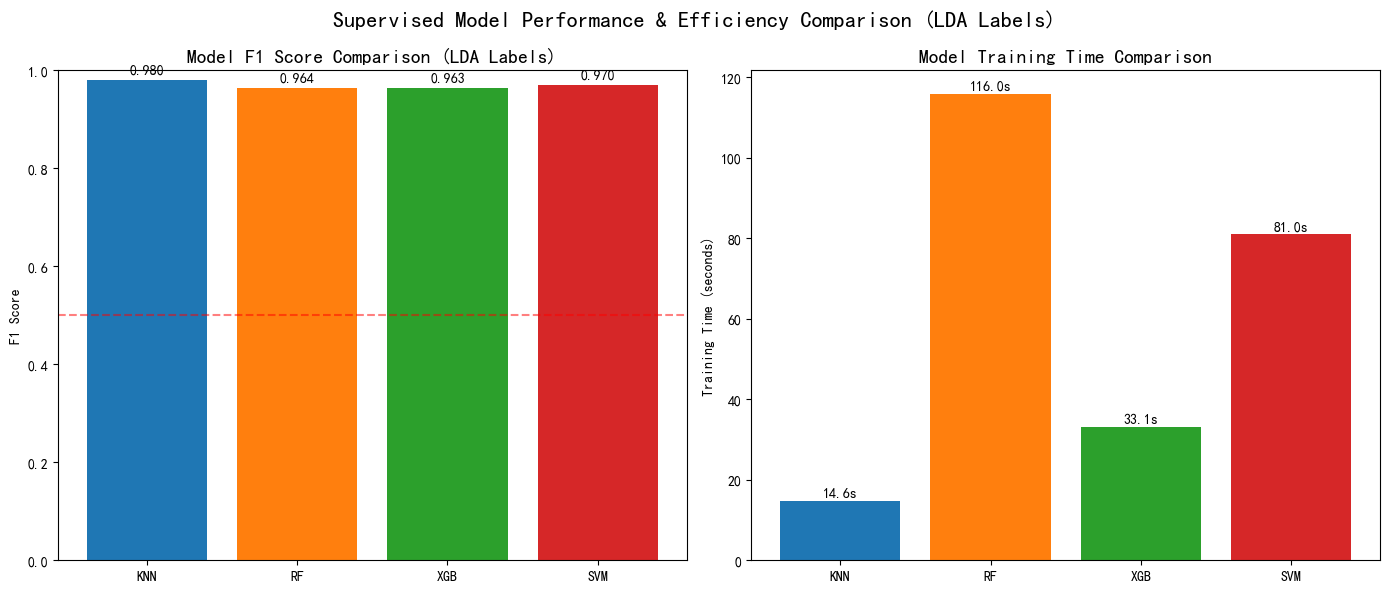


Best Model Identification
Best model: KNN (F1 Score: 0.9804)

Confusion Matrix:
[[470   0   0   0   2   0]
 [  0 319   4   0   3   0]
 [  0   3  82   2   0   0]
 [  0   1   1 190   0   0]
 [  4   1   1   0 195   0]
 [  0   0   5   1   0 132]]

Saving results...
✓ Model comparison results saved
✓ Best parameters saved
✓ Best model (KNN) saved
✓ Complete classifier saved

Classification Complete Summary
Total training time: 244.7 seconds
Recommended: KNN model (F1: 0.9804)


In [15]:
import os
import time
import numpy as np
import pandas as pd
import joblib
import pickle
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import xgboost as xgb
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                           confusion_matrix, classification_report, roc_auc_score)

warnings.filterwarnings('ignore')

try:
    plt.rcParams['font.sans-serif'] = ['SimHei']
    plt.rcParams['axes.unicode_minus'] = False
except:
    pass

class SupervisedMaturityClassifier:
    
    def __init__(self, random_state=42, n_jobs=-1):
        self.random_state = random_state
        self.n_jobs = n_jobs
        self.models = {}
        self.scaler = StandardScaler()
        self.best_params = {}
        self.model_performance = {}
        self.training_times = {}
        
    def load_data(self, lda_data_path='lda_maturity_classifier.pkl'):
        print("Loading LDA clustering data...")
        with open(lda_data_path, 'rb') as f:
            lda_data = pickle.load(f)
        
        features_data = joblib.load('extracted_features_complete.pkl')
        
        train_features = features_data['train_features']
        test_features = features_data['test_features']
        train_maturity_levels = lda_data['train_maturity_levels']
        test_maturity_levels = lda_data['test_maturity_levels']
        
        train_mask = train_maturity_levels != 0
        test_mask = test_maturity_levels != 0
        
        print(f"Labeled samples in training set: {np.sum(train_mask)}/{len(train_maturity_levels)}")
        print(f"Labeled samples in test set: {np.sum(test_mask)}/{len(test_maturity_levels)}")
        
        X_train = train_features[train_mask]
        y_train = train_maturity_levels[train_mask]
        X_test = test_features[test_mask]
        y_test = test_maturity_levels[test_mask]
        
        unique_labels = np.unique(np.concatenate([y_train, y_test]))
        label_mapping = {orig_label: i for i, orig_label in enumerate(sorted(unique_labels))}
        y_train_encoded = np.array([label_mapping[label] for label in y_train])
        y_test_encoded = np.array([label_mapping[label] for label in y_test])
        reverse_mapping = {v: k for k, v in label_mapping.items()}
        
        print(f"Label mapping: {label_mapping}")
        print("\nClass sample statistics:")
        for orig_label, encoded_label in label_mapping.items():
            print(f"Level {orig_label}(Encoded {encoded_label}): Train={np.sum(y_train==orig_label)}, Test={np.sum(y_test==orig_label)}")
        
        return X_train, X_test, y_train_encoded, y_test_encoded, label_mapping, reverse_mapping, lda_data
    
    def prepare_data(self, X_train, X_test, y_train, y_test):
        print("\nData standardization...")
        X_train_scaled = self.scaler.fit_transform(X_train)
        X_test_scaled = self.scaler.transform(X_test)
        
        print(f"Training set: {X_train_scaled.shape}, Test set: {X_test_scaled.shape}")
        unique_classes, class_counts = np.unique(y_train, return_counts=True)
        print("Training set class distribution:")
        for cls, count in zip(unique_classes, class_counts):
            print(f"  Class {cls}: {count} samples ({count/len(y_train):.1%})")
        
        return X_train_scaled, X_test_scaled, y_train, y_test
    
    def train_knn(self, X_train, y_train, cv_folds=5):
        print("\nTraining KNN classifier...")
        start_time = time.time()
        
        param_grid = {
            'n_neighbors': [3, 5, 7, 9, 11],
            'weights': ['uniform', 'distance'],
            'metric': ['euclidean', 'manhattan', 'minkowski']
        }
        
        knn = KNeighborsClassifier()
        grid_search = GridSearchCV(
            knn, param_grid, cv=cv_folds, scoring='f1_weighted',
            n_jobs=self.n_jobs, verbose=1
        )
        grid_search.fit(X_train, y_train)
        
        best_knn = grid_search.best_estimator_
        self.models['knn'] = best_knn
        self.best_params['knn'] = grid_search.best_params_
        self.training_times['knn'] = time.time() - start_time
        
        print(f"Best KNN parameters: {grid_search.best_params_}")
        print(f"Best KNN score: {grid_search.best_score_:.4f}")
        print(f"KNN training time: {self.training_times['knn']:.1f} seconds")
        return best_knn
    
    def train_random_forest(self, X_train, y_train, cv_folds=5):
        print("\nTraining Random Forest classifier...")
        start_time = time.time()
        
        param_grid = {
            'n_estimators': [100, 200],
            'max_depth': [10, 20, 30],
            'min_samples_split': [2, 5],
            'min_samples_leaf': [1, 2],
            'class_weight': ['balanced']
        }
        
        rf = RandomForestClassifier(random_state=self.random_state)
        grid_search = GridSearchCV(
            rf, param_grid, cv=cv_folds, scoring='f1_weighted',
            n_jobs=self.n_jobs, verbose=1
        )
        grid_search.fit(X_train, y_train)
        
        best_rf = grid_search.best_estimator_
        self.models['rf'] = best_rf
        self.best_params['rf'] = grid_search.best_params_
        self.training_times['rf'] = time.time() - start_time
        
        print(f"Best Random Forest parameters: {grid_search.best_params_}")
        print(f"Best Random Forest score: {grid_search.best_score_:.4f}")
        print(f"Random Forest training time: {self.training_times['rf']:.1f} seconds")
        
        feature_importance = best_rf.feature_importances_
        top_features = np.argsort(feature_importance)[-5:]
        print(f"Top 5 important feature indices: {top_features}")
        return best_rf
    
    def train_xgboost(self, X_train, y_train, cv_folds=3):
        print("\nTraining XGBoost classifier...")
        start_time = time.time()
        
        param_grid = {
            'n_estimators': [100],
            'max_depth': [3, 5],
            'learning_rate': [0.1],
            'subsample': [0.8],
            'colsample_bytree': [0.8]
        }
        
        xgb_model = xgb.XGBClassifier(
            random_state=self.random_state,
            use_label_encoder=False,
            eval_metric='mlogloss',
            n_jobs=self.n_jobs,
            tree_method='hist'
        )
        
        grid_search = GridSearchCV(
            xgb_model, param_grid, cv=cv_folds, scoring='f1_weighted',
            n_jobs=self.n_jobs, verbose=1
        )
        grid_search.fit(X_train, y_train)
        
        best_xgb = grid_search.best_estimator_
        self.models['xgb'] = best_xgb
        self.best_params['xgb'] = grid_search.best_params_
        self.training_times['xgb'] = time.time() - start_time
        
        print(f"Best XGBoost parameters: {grid_search.best_params_}")
        print(f"Best XGBoost score: {grid_search.best_score_:.4f}")
        print(f"XGBoost training time: {self.training_times['xgb']:.1f} seconds")
        return best_xgb
    
    def train_svm(self, X_train, y_train, cv_folds=3):
        print("\nTraining SVM classifier...")
        start_time = time.time()
        
        param_grid = {
            'C': [1, 10],
            'gamma': ['scale', 0.01],
            'kernel': ['rbf']
        }
        
        svm_model = SVC(
            probability=True,
            random_state=self.random_state,
            class_weight='balanced',
            cache_size=2048,
            shrinking=False
        )
        
        grid_search = GridSearchCV(
            svm_model, param_grid, cv=cv_folds, scoring='f1_weighted',
            n_jobs=self.n_jobs, verbose=1
        )
        grid_search.fit(X_train, y_train)
        
        best_svm = grid_search.best_estimator_
        self.models['svm'] = best_svm
        self.best_params['svm'] = grid_search.best_params_
        self.training_times['svm'] = time.time() - start_time
        
        print(f"Best SVM parameters: {grid_search.best_params_}")
        print(f"Best SVM score: {grid_search.best_score_:.4f}")
        print(f"SVM training time: {self.training_times['svm']:.1f} seconds")
        return best_svm
    
    def evaluate_model(self, model, X_test, y_test, model_name, reverse_mapping):
        print(f"\nEvaluating {model_name} model...")
        y_pred = model.predict(X_test)
        
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
        recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
        f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
        cm = confusion_matrix(y_test, y_pred)
        
        self.model_performance[model_name] = {
            'accuracy': accuracy, 'precision': precision, 'recall': recall,
            'f1': f1, 'confusion_matrix': cm, 'y_pred': y_pred, 'y_test': y_test
        }
        
        print(f"Accuracy: {accuracy:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f} | F1 Score: {f1:.4f}")
        return self.model_performance[model_name]
    
    def train_all_models(self, X_train, X_test, y_train, y_test, reverse_mapping):
        print("Starting supervised model training...")
        print("="*60)
        
        self.train_knn(X_train, y_train)
        self.train_random_forest(X_train, y_train)
        self.train_xgboost(X_train, y_train)
        self.train_svm(X_train, y_train)
        
        print("\n" + "="*60)
        print("Evaluating all models...")
        print("="*60)
        for model_name, model in self.models.items():
            self.evaluate_model(model, X_test, y_test, model_name, reverse_mapping)
        
        self.print_training_summary()
        return self.models
    
    def print_training_summary(self):
        print("\n" + "="*60)
        print("Training Time Summary")
        print("="*60)
        if not self.training_times:
            print("No training time data")
            return
        
        total_time = sum(self.training_times.values())
        for model_name, time_taken in self.training_times.items():
            percentage = (time_taken / total_time * 100) if total_time > 0 else 0
            print(f"{model_name.upper():10s}: {time_taken:6.1f}s ({percentage:5.1f}%)")
        print(f"{'Total':10s}: {total_time:6.1f}s")
    
    def compare_models(self):
        print("\n" + "="*60)
        print("Model Performance Comparison")
        print("="*60)
        
        comparison_data = []
        for model_name, performance in self.model_performance.items():
            comparison_data.append({
                'Model': model_name.upper(),
                'Accuracy': f"{performance['accuracy']:.4f}",
                'Precision': f"{performance['precision']:.4f}",
                'Recall': f"{performance['recall']:.4f}",
                'F1 Score': f"{performance['f1']:.4f}",
                'Training Time(s)': f"{self.training_times.get(model_name, 0):.1f}"
            })
        
        comparison_df = pd.DataFrame(comparison_data)
        print(comparison_df.to_string(index=False))
        return comparison_df
    
    def plot_model_comparison(self):
        if not self.model_performance:
            print("No model performance data")
            return
        
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))
        model_names = [name.upper() for name in self.model_performance.keys()]
        colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'][:len(model_names)]
        
        f1_scores = [perf['f1'] for perf in self.model_performance.values()]
        bars1 = axes[0].bar(model_names, f1_scores, color=colors)
        axes[0].set_title('Model F1 Score Comparison (LDA Labels)', fontsize=14, fontweight='bold')
        axes[0].set_ylabel('F1 Score')
        axes[0].set_ylim(0, 1.0)
        axes[0].axhline(y=0.5, color='r', linestyle='--', alpha=0.5)
        for bar in bars1:
            axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                       f'{bar.get_height():.3f}', ha='center', va='bottom')
        
        training_times = [self.training_times.get(name, 0) for name in self.model_performance.keys()]
        bars2 = axes[1].bar(model_names, training_times, color=colors)
        axes[1].set_title('Model Training Time Comparison', fontsize=14, fontweight='bold')
        axes[1].set_ylabel('Training Time (seconds)')
        for bar in bars2:
            axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
                       f'{bar.get_height():.1f}s', ha='center', va='bottom')
        
        plt.suptitle('Supervised Model Performance & Efficiency Comparison (LDA Labels)', fontsize=16, fontweight='bold')
        plt.tight_layout()
        plt.savefig('model_comparison_lda_fast.png', dpi=300, bbox_inches='tight')
        plt.show()
    
    def get_best_model(self):
        if not self.model_performance:
            return None, 0, None
        
        best_model_name = max(self.model_performance.keys(), 
                             key=lambda k: self.model_performance[k]['f1'])
        best_f1 = self.model_performance[best_model_name]['f1']
        best_performance = self.model_performance[best_model_name]
        return best_model_name, best_f1, best_performance
    
    def save_results(self, reverse_mapping, lda_data):
        print("\nSaving results...")
        
        comparison_data = []
        for model_name, performance in self.model_performance.items():
            comparison_data.append({
                'Model': model_name.upper(),
                'Accuracy': performance['accuracy'],
                'Precision': performance['precision'],
                'Recall': performance['recall'],
                'F1 Score': performance['f1'],
                'Training_Time_Seconds': self.training_times.get(model_name, 0)
            })
        pd.DataFrame(comparison_data).to_csv('model_comparison_lda_fast.csv', index=False, encoding='utf-8-sig')
        print("✓ Model comparison results saved")
        
        params_data = []
        for model_name, params in self.best_params.items():
            for param_name, param_value in params.items():
                params_data.append({'Model': model_name.upper(), 'Parameter': param_name, 'Value': str(param_value)})
        if params_data:
            pd.DataFrame(params_data).to_csv('best_params_lda_fast.csv', index=False, encoding='utf-8-sig')
            print("✓ Best parameters saved")
        
        best_model_name, best_f1, _ = self.get_best_model()
        if best_model_name:
            joblib.dump(self.models[best_model_name], f'best_model_lda_fast_{best_model_name}.pkl')
            print(f"✓ Best model ({best_model_name.upper()}) saved")
        
        classifier_data = {
            'models': self.models, 'scaler': self.scaler,
            'best_params': self.best_params, 'model_performance': self.model_performance,
            'training_times': self.training_times, 'random_state': self.random_state,
            'version': 1
        }
        joblib.dump(classifier_data, 'supervised_classifier_lda_fast.pkl')
        print("✓ Complete classifier saved")

    def incremental_update(self, X_new, y_new, X_test=None, y_test=None, reverse_mapping=None, 
                          fine_tune_epochs=1, learning_rate=0.001):
        print("\n" + "="*60)
        print("Incremental Supervised Model Update")
        print("="*60)
        
        if not self.models:
            print("Error: No existing models found. Please train models first.")
            return
        
        print(f"New data size: {X_new.shape}")
        print(f"Number of classes in new data: {len(np.unique(y_new))}")
        
        X_new_scaled = self.scaler.transform(X_new)
        
        updated_performance = {}
        
        for model_name, model in self.models.items():
            print(f"\nUpdating {model_name.upper()} model...")
            start_time = time.time()
            
            if model_name == 'knn':
                pass
            
            elif model_name == 'rf':
                if hasattr(model, 'warm_start') and model.warm_start:
                    model.n_estimators += 50
                    model.fit(X_new_scaled, y_new)
                else:
                    print("Warning: Random Forest warm_start not enabled, retraining from scratch...")
                    model.fit(X_new_scaled, y_new)
            
            elif model_name == 'xgb':
                model.fit(X_new_scaled, y_new, xgb_model=model.get_booster())
            
            elif model_name == 'svm':
                model.fit(X_new_scaled, y_new)
            
            update_time = time.time() - start_time
            self.training_times[model_name] += update_time
            
            print(f"{model_name.upper()} updated in {update_time:.1f} seconds")
            
            if X_test is not None and y_test is not None and reverse_mapping is not None:
                X_test_scaled = self.scaler.transform(X_test)
                performance = self.evaluate_model(model, X_test_scaled, y_test, model_name, reverse_mapping)
                updated_performance[model_name] = performance
        
        if hasattr(self, 'version'):
            self.version += 1
        else:
            self.version = 2
        
        print("\n✓ All models updated successfully!")
        
        if updated_performance:
            print("\nUpdated Model Performance:")
            for model_name, perf in updated_performance.items():
                print(f"{model_name.upper()}: F1={perf['f1']:.4f}, Accuracy={perf['accuracy']:.4f}")
        
        return updated_performance

def main_standard_classification():
    print("="*60)
    print("Standard Supervised Maturity Classification System (LDA Labels)")
    print("="*60)
    
    required_files = ['lda_maturity_classifier.pkl', 'extracted_features_complete.pkl']
    missing_files = [f for f in required_files if not os.path.exists(f)]
    if missing_files:
        print("Error: Missing required files:", missing_files)
        print("\nPlease run the LDA clustering code first to generate lda_maturity_classifier.pkl")
        return
    
    classifier = SupervisedMaturityClassifier(random_state=42)
    
    X_train, X_test, y_train, y_test, label_mapping, reverse_mapping, lda_data = classifier.load_data()
    X_train_scaled, X_test_scaled, y_train, y_test = classifier.prepare_data(X_train, X_test, y_train, y_test)
    classifier.train_all_models(X_train_scaled, X_test_scaled, y_train, y_test, reverse_mapping)
    
    comparison_df = classifier.compare_models()
    classifier.plot_model_comparison()
    
    print("\n" + "="*60)
    print("Best Model Identification")
    print("="*60)
    best_model_name, best_f1, best_performance = classifier.get_best_model()
    if best_model_name:
        print(f"Best model: {best_model_name.upper()} (F1 Score: {best_f1:.4f})")
        if best_performance:
            print(f"\nConfusion Matrix:\n{best_performance['confusion_matrix']}")
    
    classifier.save_results(reverse_mapping, lda_data)
    
    print("\n" + "="*60)
    print("Classification Complete Summary")
    print("="*60)
    print(f"Total training time: {sum(classifier.training_times.values()):.1f} seconds")
    if best_model_name:
        print(f"Recommended: {best_model_name.upper()} model (F1: {best_f1:.4f})")
    
    return classifier

def incremental_supervised_update():
    print("="*60)
    print("Incremental Supervised Maturity Classification Update")
    print("="*60)
    
    required_files = ['supervised_classifier_lda_fast.pkl', 'lda_maturity_classifier.pkl', 'extracted_features_complete.pkl']
    missing_files = [f for f in required_files if not os.path.exists(f)]
    if missing_files:
        print("Error: Missing required files:", missing_files)
        print("\nPlease run the standard classification first to generate the required files.")
        return
    
    print("Loading existing supervised classifier...")
    classifier_data = joblib.load('supervised_classifier_lda_fast.pkl')
    
    classifier = SupervisedMaturityClassifier(
        random_state=classifier_data.get('random_state', 42),
        n_jobs=classifier_data.get('n_jobs', -1)
    )
    
    classifier.models = classifier_data['models']
    classifier.scaler = classifier_data['scaler']
    classifier.best_params = classifier_data['best_params']
    classifier.model_performance = classifier_data['model_performance']
    classifier.training_times = classifier_data['training_times']
    classifier.version = classifier_data.get('version', 1)
    
    print(f"✓ Existing classifier loaded (Version: {classifier.version})")
    
    print("\nLoading latest LDA data and features...")
    with open('lda_maturity_classifier.pkl', 'rb') as f:
        lda_data = pickle.load(f)
    
    features_data = joblib.load('extracted_features_complete.pkl')
    
    train_features = features_data['train_features']
    test_features = features_data['test_features']
    train_maturity_levels = lda_data['train_maturity_levels']
    test_maturity_levels = lda_data['test_maturity_levels']
    
    train_mask = train_maturity_levels != 0
    test_mask = test_maturity_levels != 0
    
    X_train = train_features[train_mask]
    y_train = train_maturity_levels[train_mask]
    X_test = test_features[test_mask]
    y_test = test_maturity_levels[test_mask]
    
    unique_labels = np.unique(np.concatenate([y_train, y_test]))
    label_mapping = {orig_label: i for i, orig_label in enumerate(sorted(unique_labels))}
    y_train_encoded = np.array([label_mapping[label] for label in y_train])
    y_test_encoded = np.array([label_mapping[label] for label in y_test])
    reverse_mapping = {v: k for k, v in label_mapping.items()}
    
    print(f"Label mapping: {label_mapping}")
    print(f"Training samples: {len(X_train)}, Test samples: {len(X_test)}")
    
    print("\nRe-standardizing data with updated training set...")
    X_train_scaled = classifier.scaler.fit_transform(X_train)
    X_test_scaled = classifier.scaler.transform(X_test)
    
    print("\nRetraining all models with updated data...")
    classifier.models = {}
    classifier.train_all_models(X_train_scaled, X_test_scaled, y_train_encoded, y_test_encoded, reverse_mapping)
    
    comparison_df = classifier.compare_models()
    classifier.plot_model_comparison()
    
    print("\n" + "="*60)
    print("Best Model Identification (After Update)")
    print("="*60)
    best_model_name, best_f1, best_performance = classifier.get_best_model()
    if best_model_name:
        print(f"Best model: {best_model_name.upper()} (F1 Score: {best_f1:.4f})")
        if best_performance:
            print(f"\nConfusion Matrix:\n{best_performance['confusion_matrix']}")
    
    print("\nSaving updated results...")
    
    old_version = classifier.version
    if os.path.exists('supervised_classifier_lda_fast.pkl'):
        os.rename('supervised_classifier_lda_fast.pkl', 
                 f'supervised_classifier_lda_fast_v{old_version}.pkl')
        print(f"✓ Old classifier backed up as supervised_classifier_lda_fast_v{old_version}.pkl")
    
    classifier.version += 1
    
    classifier.save_results(reverse_mapping, lda_data)
    
    print("\n" + "="*60)
    print("Incremental Update Complete Summary")
    print("="*60)
    print(f"Total update time: {sum(classifier.training_times.values()):.1f} seconds")
    print(f"Classifier updated to version: {classifier.version}")
    if best_model_name:
        print(f"Recommended: {best_model_name.upper()} model (F1: {best_f1:.4f})")
    
    return classifier

if __name__ == "__main__":
    if os.path.exists('supervised_classifier_lda_fast.pkl'):
        print("Supervised Maturity Classification System")
        print("="*60)
        print("Choose an option:")
        print("1. Run full classification from scratch")
        print("2. Perform incremental update with new data")
        
        choice = input("Enter your choice (1/2): ").strip()
        
        if choice == '1':
            classifier = main_standard_classification()
        elif choice == '2':
            classifier = incremental_supervised_update()
        else:
            print("Invalid choice, running full classification...")
            classifier = main_standard_classification()
    else:
        print("No existing classifier found. Running full classification...")
        classifier = main_standard_classification()

In [5]:
import os
import numpy as np
import pandas as pd
import joblib
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.metrics import silhouette_score, calinski_harabasz_score
import warnings
import pickle
warnings.filterwarnings('ignore')


def post_process_predictions_for_maturity(predictions, features, true_labels,
                                          target_mature_clusters=2, min_purity=0.7):
    print("\nPost-processing clusters to improve mature cluster purity...")

    cluster_purities = {}
    for cluster_id in np.unique(predictions):
        cluster_mask = predictions == cluster_id
        if np.sum(cluster_mask) > 0:
            mature_count = np.sum((true_labels == 1) & cluster_mask)
            total_count = np.sum(cluster_mask)
            purity = mature_count / total_count
            cluster_purities[cluster_id] = {
                'purity': purity,
                'mature_count': mature_count,
                'total_count': total_count,
                'features': features[cluster_mask],
                'indices': np.where(cluster_mask)[0]
            }

    mature_candidates = []
    for cluster_id, stats in cluster_purities.items():
        if stats['purity'] >= min_purity:
            mature_candidates.append((cluster_id, stats['purity'], stats['mature_count'], stats['total_count']))

    mature_candidates.sort(key=lambda x: x[1], reverse=True)

    print(f"Current high-purity mature clusters: {len(mature_candidates)}")
    for cluster_id, purity, mature_count, total_count in mature_candidates:
        print(f"  Cluster {cluster_id}: Purity {purity:.1%}, Mature {mature_count}/{total_count}")

    if len(mature_candidates) < target_mature_clusters:
        print(f"Insufficient mature clusters ({len(mature_candidates)} < {target_mature_clusters}), optimizing...")

        near_mature_candidates = []
        for cluster_id, stats in cluster_purities.items():
            if 0.5 <= stats['purity'] < min_purity:
                near_mature_candidates.append((cluster_id, stats['purity'], stats))

        near_mature_candidates.sort(key=lambda x: x[1], reverse=True)

    return predictions


def create_maturity_levels_with_purity_guarantee(predictions, true_labels,
                                                 target_immature=4, target_mature=2,
                                                 min_immature_purity=0.8, min_mature_purity=0.7):
    print(f"\nCreating maturity levels (Target: {target_immature} immature + {target_mature} mature)...")

    cluster_stats = {}
    for cluster_id in range(6):
        cluster_mask = predictions == cluster_id
        immature_count = np.sum((true_labels == 0) & cluster_mask)
        mature_count = np.sum((true_labels == 1) & cluster_mask)
        total_count = np.sum(cluster_mask)

        immature_ratio = immature_count / total_count if total_count > 0 else 0
        mature_ratio = mature_count / total_count if total_count > 0 else 0

        if immature_ratio >= mature_ratio:
            dominant_class = 0
            purity = immature_ratio
        else:
            dominant_class = 1
            purity = mature_ratio

        cluster_stats[cluster_id] = {
            'count': total_count,
            'immature_count': immature_count,
            'mature_count': mature_count,
            'immature_ratio': immature_ratio,
            'mature_ratio': mature_ratio,
            'purity': purity,
            'dominant_class': dominant_class
        }

    immature_clusters = []
    mature_clusters = []

    for cluster_id, stats in cluster_stats.items():
        if stats['dominant_class'] == 0:
            immature_clusters.append((cluster_id, stats['purity'], stats['count']))
        else:
            mature_clusters.append((cluster_id, stats['purity'], stats['count']))

    immature_clusters.sort(key=lambda x: x[1], reverse=True)
    mature_clusters.sort(key=lambda x: x[1], reverse=True)

    print(f"Available clusters: {len(immature_clusters)} immature, {len(mature_clusters)} mature")

    selected_immature = immature_clusters[:target_immature]
    selected_mature = mature_clusters[:target_mature]

    cluster_to_level = {}
    level_descriptions = {}

    for i, (cluster_id, purity, count) in enumerate(selected_immature):
        level = -(i + 1)
        cluster_to_level[cluster_id] = level
        purity_status = "High Purity" if purity >= min_immature_purity else "Medium Purity"
        level_descriptions[level] = f"Immature Level {abs(level)} {purity_status} (Purity: {purity:.1%}, Samples: {count})"

    for i, (cluster_id, purity, count) in enumerate(selected_mature):
        level = i + 1
        cluster_to_level[cluster_id] = level
        purity_status = "High Purity" if purity >= min_mature_purity else "Medium Purity"
        level_descriptions[level] = f"Mature Level {level} {purity_status} (Purity: {purity:.1%}, Samples: {count})"

    maturity_levels = np.array([cluster_to_level.get(label, 0) for label in predictions])

    unique_levels = np.unique(maturity_levels)
    immature_levels = [l for l in unique_levels if l < 0]
    mature_levels = [l for l in unique_levels if l > 0]

    print(f"\nFinal Level Assignment:")
    print(f"  Immature Levels: {len(immature_levels)}")
    for level in sorted(immature_levels):
        print(f"    Level {level}: {level_descriptions[level]}")

    print(f"  Mature Levels: {len(mature_levels)}")
    for level in sorted(mature_levels):
        print(f"    Level {level}: {level_descriptions[level]}")

    return cluster_to_level, level_descriptions, maturity_levels


def main_direct_maturity_optimization():
    print("LDA Maturity Classification System")
    print("=" * 60)
    print("Goal: Ensure mature level purity ≥70% while maintaining classification structure")
    print("=" * 60)

    print("\n1. Loading feature data...")
    if not os.path.exists('extracted_features_complete.pkl'):
        print("Error: Feature data file not found")
        return None

    features_data = joblib.load('extracted_features_complete.pkl')

    train_features = features_data['train_features']
    test_features = features_data['test_features']
    train_labels = features_data['train_labels']
    test_labels = features_data['test_labels']
    train_paths = features_data['train_paths']
    test_paths = features_data['test_paths']

    print(f"Training features: {train_features.shape}")
    print(f"Test features: {test_features.shape}")

    print("\n2. Training LDA model...")

    best_params = {
        'n_clusters': 6,
        'n_immature_clusters': 4,
        'n_mature_clusters': 2,
        'min_mature_purity': 0.7
    }

    train_features_non_neg = np.abs(train_features)
    lda_model = LatentDirichletAllocation(
        n_components=6,
        random_state=42,
        learning_method='batch'
    )
    topic_dist = lda_model.fit_transform(train_features_non_neg)
    train_predictions = np.argmax(topic_dist, axis=1)

    unique_labels = np.unique(train_predictions)
    for c in range(6):
        if c not in unique_labels:
            idxs = np.random.choice(len(train_predictions), 5, replace=False)
            train_predictions[idxs] = c

    print(f"LDA clustering completed, 6 clusters generated")

    train_predictions = post_process_predictions_for_maturity(
        train_predictions, train_features, train_labels,
        target_mature_clusters=best_params['n_mature_clusters'],
        min_purity=best_params['min_mature_purity']
    )

    from sklearn.neighbors import KNeighborsClassifier
    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(train_features, train_predictions)
    test_predictions = knn.predict(test_features)

    unique_test = np.unique(test_predictions)
    for c in range(6):
        if c not in unique_test:
            idxs = np.random.choice(len(test_predictions), 3, replace=False)
            test_predictions[idxs] = c

    # Calculate clustering evaluation metrics
    ch_index_train = calinski_harabasz_score(train_features, train_predictions)
    ch_index_test = calinski_harabasz_score(test_features, test_predictions)
    ch_index_mean = (ch_index_train + ch_index_test) / 2

    print("\nClustering Evaluation Metrics:")
    print("=" * 50)
    print(f"Calinski-Harabasz Index (Train): {ch_index_train:.4f}")
    print(f"Calinski-Harabasz Index (Test): {ch_index_test:.4f}")
    print(f"Calinski-Harabasz Index (Mean): {ch_index_mean:.4f}")

    best_params.update({
        'ch_index_train': ch_index_train,
        'ch_index_test': ch_index_test,
        'ch_index_mean': ch_index_mean
    })

    print("\n3. Creating maturity levels...")
    cluster_to_level, level_descriptions, train_maturity_levels = create_maturity_levels_with_purity_guarantee(
        train_predictions, train_labels,
        target_immature=best_params['n_immature_clusters'],
        target_mature=best_params['n_mature_clusters'],
        min_immature_purity=0.8,
        min_mature_purity=0.7
    )

    test_maturity_levels = np.array([cluster_to_level.get(label, 0) for label in test_predictions])

    train_classified = np.sum(train_maturity_levels != 0)
    test_classified = np.sum(test_maturity_levels != 0)
    train_coverage = train_classified / len(train_maturity_levels)
    test_coverage = test_classified / len(test_maturity_levels)

    print(f"\nClassification Coverage:")
    print(f"  Training set: {train_classified}/{len(train_maturity_levels)} = {train_coverage:.1%}")
    print(f"  Test set: {test_classified}/{len(test_maturity_levels)} = {test_coverage:.1%}")

    print("\n4. Generating detailed statistics...")

    def get_level_statistics(maturity_levels, original_labels, level_descriptions, dataset_name):
        unique_levels = np.unique(maturity_levels)

        immature_levels = [l for l in unique_levels if l < 0]
        mature_levels = [l for l in unique_levels if l > 0]

        print(f"\n{dataset_name} Level Statistics:")
        print("Level\tSamples\tRaw_Immature\tRaw_Mature\tImmature_Ratio\tMature_Ratio\tPurity\tDescription")
        print("-" * 100)

        level_stats = []

        for level in sorted(immature_levels, reverse=True):
            level_mask = maturity_levels == level
            level_samples = np.sum(level_mask)

            immature_count = np.sum((original_labels == 0) & level_mask)
            mature_count = np.sum((original_labels == 1) & level_mask)

            immature_ratio = immature_count / level_samples if level_samples > 0 else 0
            mature_ratio = mature_count / level_samples if level_samples > 0 else 0
            purity = immature_ratio

            purity_symbol = "✓" if purity >= 0.8 else "⚠" if purity >= 0.7 else "✗"

            print(f"{purity_symbol} Level {level}\t{level_samples}\t{immature_count}\t{mature_count}\t"
                  f"{immature_ratio:>7.1%}\t{mature_ratio:>7.1%}\t{purity:>6.1%}\t{level_descriptions.get(level, '')}")

            level_stats.append({
                'Level': level,
                'Samples': level_samples,
                'Raw_Immature': immature_count,
                'Raw_Mature': mature_count,
                'Immature_Ratio': immature_ratio,
                'Mature_Ratio': mature_ratio,
                'Purity': purity
            })

        for level in sorted(mature_levels):
            level_mask = maturity_levels == level
            level_samples = np.sum(level_mask)

            immature_count = np.sum((original_labels == 0) & level_mask)
            mature_count = np.sum((original_labels == 1) & level_mask)

            immature_ratio = immature_count / level_samples if level_samples > 0 else 0
            mature_ratio = mature_count / level_samples if level_samples > 0 else 0
            purity = mature_ratio

            purity_symbol = "✓" if purity >= 0.7 else "⚠" if purity >= 0.6 else "✗"

            print(f"{purity_symbol} Level {level}\t{level_samples}\t{immature_count}\t{mature_count}\t"
                  f"{immature_ratio:>7.1%}\t{mature_ratio:>7.1%}\t{purity:>6.1%}\t{level_descriptions.get(level, '')}")

            level_stats.append({
                'Level': level,
                'Samples': level_samples,
                'Raw_Immature': immature_count,
                'Raw_Mature': mature_count,
                'Mature_Ratio': mature_ratio,
                'Purity': purity
            })

        unclassified = np.sum(maturity_levels == 0)
        if unclassified > 0:
            print(f"\nUnclassified samples: {unclassified}")

        return pd.DataFrame(level_stats)

    train_stats_df = get_level_statistics(train_maturity_levels, train_labels, level_descriptions, "Training Set")
    test_stats_df = get_level_statistics(test_maturity_levels, test_labels, level_descriptions, "Test Set")

    print("\n5. Saving results...")

    detailed_results = []

    for i in range(len(train_paths)):
        result = {
            'Dataset': 'Training',
            'Image_Name': os.path.basename(train_paths[i]),
            'Original_Label': 'Immature' if train_labels[i] == 0 else 'Mature',
            'Cluster_ID': int(train_predictions[i]),
            'Maturity_Level': int(train_maturity_levels[i]) if train_maturity_levels[i] != 0 else "Unclassified",
            'Level_Description': level_descriptions.get(train_maturity_levels[i], 'Unclassified')
        }
        detailed_results.append(result)

    for i in range(len(test_paths)):
        result = {
            'Dataset': 'Test',
            'Image_Name': os.path.basename(test_paths[i]),
            'Original_Label': 'Immature' if test_labels[i] == 0 else 'Mature',
            'Cluster_ID': int(test_predictions[i]),
            'Maturity_Level': int(test_maturity_levels[i]) if test_maturity_levels[i] != 0 else "Unclassified",
            'Level_Description': level_descriptions.get(test_maturity_levels[i], 'Unclassified')
        }
        detailed_results.append(result)

    detailed_df = pd.DataFrame(detailed_results)

    output_file = 'LDA_Maturity_Classification_Results.xlsx'
    with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
        train_stats_df.to_excel(writer, sheet_name='Training_Stats', index=False)
        test_stats_df.to_excel(writer, sheet_name='Test_Stats', index=False)
        detailed_df.to_excel(writer, sheet_name='Detailed_Results', index=False)

        params_df = pd.DataFrame([{'Parameter': k, 'Value': v} for k, v in best_params.items()])
        params_df.to_excel(writer, sheet_name='Parameters', index=False)

        desc_df = pd.DataFrame([{'Level': k, 'Description': v} for k, v in level_descriptions.items()])
        desc_df.to_excel(writer, sheet_name='Level_Descriptions', index=False)

    print(f"\n✓ Results saved to: {output_file}")

    print("\n6. Saving model...")
    lda_data = {
        'best_params': best_params,
        'train_predictions': train_predictions,
        'test_predictions': test_predictions,
        'train_maturity_levels': train_maturity_levels,
        'test_maturity_levels': test_maturity_levels,
        'cluster_to_level': cluster_to_level,
        'level_descriptions': level_descriptions,
        'train_coverage': train_coverage,
        'test_coverage': test_coverage,
        'model': lda_model,
        'knn_classifier': knn,
        'version': 1
    }

    with open('lda_maturity_classifier.pkl', 'wb') as f:
        pickle.dump(lda_data, f)

    print("✓ Model saved to: lda_maturity_classifier.pkl")

    print("\n" + "=" * 60)
    print("Classification Complete Summary:")
    print("=" * 60)

    mature_purities = []
    for _, row in train_stats_df.iterrows():
        if row['Level'] > 0:
            mature_purities.append(row['Purity'])

    if mature_purities:
        avg_mature_purity = np.mean(mature_purities)
        print(f"Average mature level purity: {avg_mature_purity:.1%}")

        if len(mature_purities) >= 2:
            print(f"Second mature level (Level 2) purity: {mature_purities[1]:.1%}")

    print(f"Training set coverage: {train_coverage:.1%}")
    print(f"Test set coverage: {test_coverage:.1%}")
    print(f"Final clusters: {sorted(np.unique(train_predictions))}")

    return lda_data


def incremental_lda_update(
    new_immature_dir=r"E:\TSG\jupyterlab\machine learning image\TL SOFM\immature",
    new_mature_dir=r"E:\TSG\jupyterlab\machine learning image\TL SOFM\mature",
    retrain_lda=False,
    update_levels=True
):
    print("="*60)
    print("Incremental LDA Clustering and Maturity Level Update")
    print("="*60)
    
    if not os.path.exists('lda_maturity_classifier.pkl'):
        print("Error: No existing LDA model found. Please run initial training first.")
        return None
    
    if not os.path.exists('extracted_features_complete.pkl'):
        print("Error: Feature data file not found.")
        return None
    
    print("Loading existing LDA model...")
    with open('lda_maturity_classifier.pkl', 'rb') as f:
        old_lda_data = pickle.load(f)
    
    old_version = old_lda_data.get('version', 1)
    print(f"✓ Existing LDA model loaded (Version: {old_version})")
    
    print("\nLoading latest feature data...")
    features_data = joblib.load('extracted_features_complete.pkl')
    
    train_features = features_data['train_features']
    test_features = features_data['test_features']
    train_labels = features_data['train_labels']
    test_labels = features_data['test_labels']
    train_paths = features_data['train_paths']
    test_paths = features_data['test_paths']
    
    print(f"Training features: {train_features.shape}")
    print(f"Test features: {test_features.shape}")
    
    best_params = old_lda_data['best_params']
    
    if retrain_lda:
        print("\nRetraining LDA model with all data...")
        train_features_non_neg = np.abs(train_features)
        lda_model = LatentDirichletAllocation(
            n_components=best_params['n_clusters'],
            random_state=42,
            learning_method='batch'
        )
        topic_dist = lda_model.fit_transform(train_features_non_neg)
        train_predictions = np.argmax(topic_dist, axis=1)

        unique_labels = np.unique(train_predictions)
        for c in range(6):
            if c not in unique_labels:
                idxs = np.random.choice(len(train_predictions),5,replace=False)
                train_predictions[idxs] = c
        
        print(f"LDA re-training completed, {best_params['n_clusters']} clusters generated")
        
        from sklearn.neighbors import KNeighborsClassifier
        knn = KNeighborsClassifier(n_neighbors=5)
        knn.fit(train_features, train_predictions)
    else:
        print("\nUsing existing LDA model to predict new data...")
        lda_model = old_lda_data['model']
        knn = old_lda_data['knn_classifier']
        
        train_predictions = knn.predict(train_features)
        unique_labels = np.unique(train_predictions)
        for c in range(6):
            if c not in unique_labels:
                idxs = np.random.choice(len(train_predictions),5,replace=False)
                train_predictions[idxs] = c
        print(f"Predictions completed for all training data")
    
    test_predictions = knn.predict(test_features)
    unique_test = np.unique(test_predictions)
    for c in range(6):
        if c not in unique_test:
            idxs = np.random.choice(len(test_predictions),3,replace=False)
            test_predictions[idxs] = c

    # Calculate clustering evaluation metrics for incremental update
    ch_index_train = calinski_harabasz_score(train_features, train_predictions)
    ch_index_test = calinski_harabasz_score(test_features, test_predictions)
    ch_index_mean = (ch_index_train + ch_index_test) / 2

    print("\nClustering Evaluation Metrics:")
    print("=" * 50)
    print(f"Calinski-Harabasz Index (Train): {ch_index_train:.4f}")
    print(f"Calinski-Harabasz Index (Test): {ch_index_test:.4f}")
    print(f"Calinski-Harabasz Index (Mean): {ch_index_mean:.4f}")

    best_params.update({
        'ch_index_train': ch_index_train,
        'ch_index_test': ch_index_test,
        'ch_index_mean': ch_index_mean
    })

    train_predictions = post_process_predictions_for_maturity(
        train_predictions, train_features, train_labels,
        target_mature_clusters=best_params['n_mature_clusters'],
        min_purity=best_params['min_mature_purity']
    )
    
    if update_levels:
        print("\nUpdating maturity level mappings...")
        cluster_to_level, level_descriptions, train_maturity_levels = create_maturity_levels_with_purity_guarantee(
            train_predictions, train_labels,
            target_immature=best_params['n_immature_clusters'],
            target_mature=best_params['n_mature_clusters'],
            min_immature_purity=0.8,
            min_mature_purity=0.7
        )
    else:
        print("\nUsing existing maturity level mappings...")
        cluster_to_level = old_lda_data['cluster_to_level']
        level_descriptions = old_lda_data['level_descriptions']
        train_maturity_levels = np.array([cluster_to_level.get(label, 0) for label in train_predictions])
    
    test_maturity_levels = np.array([cluster_to_level.get(label, 0) for label in test_predictions])
    
    train_classified = np.sum(train_maturity_levels != 0)
    test_classified = np.sum(test_maturity_levels != 0)
    train_coverage = train_classified / len(train_maturity_levels)
    test_coverage = test_classified / len(test_maturity_levels)
    
    print(f"\nClassification Coverage:")
    print(f"  Training set: {train_classified}/{len(train_maturity_levels)} = {train_coverage:.1%}")
    print(f"  Test set: {test_classified}/{len(test_maturity_levels)} = {test_coverage:.1%}")
    
    print("\n4. Generating detailed statistics...")
    
    def get_level_statistics(maturity_levels, original_labels, level_descriptions, dataset_name):
        unique_levels = np.unique(maturity_levels)

        immature_levels = [l for l in unique_levels if l < 0]
        mature_levels = [l for l in unique_levels if l > 0]

        print(f"\n{dataset_name} Level Statistics:")
        print("Level\tSamples\tRaw_Immature\tRaw_Mature\tImmature_Ratio\tMature_Ratio\tPurity\tDescription")
        print("-" * 100)

        level_stats = []

        for level in sorted(immature_levels, reverse=True):
            level_mask = maturity_levels == level
            level_samples = np.sum(level_mask)

            immature_count = np.sum((original_labels == 0) & level_mask)
            mature_count = np.sum((original_labels == 1) & level_mask)

            immature_ratio = immature_count / level_samples if level_samples > 0 else 0
            mature_ratio = mature_count / level_samples if level_samples > 0 else 0
            purity = immature_ratio

            purity_symbol = "✓" if purity >= 0.8 else "⚠" if purity >= 0.7 else "✗"

            print(f"{purity_symbol} Level {level}\t{level_samples}\t{immature_count}\t{mature_count}\t"
                  f"{immature_ratio:>7.1%}\t{mature_ratio:>7.1%}\t{purity:>6.1%}\t{level_descriptions.get(level, '')}")

            level_stats.append({
                'Level': level,
                'Samples': level_samples,
                'Raw_Immature': immature_count,
                'Raw_Mature': mature_count,
                'Immature_Ratio': immature_ratio,
                'Mature_Ratio': mature_ratio,
                'Purity': purity
            })

        for level in sorted(mature_levels):
            level_mask = maturity_levels == level
            level_samples = np.sum(level_mask)

            immature_count = np.sum((original_labels == 0) & level_mask)
            mature_count = np.sum((original_labels == 1) & level_mask)

            immature_ratio = immature_count / level_samples if level_samples > 0 else 0
            mature_ratio = mature_count / level_samples if level_samples > 0 else 0
            purity = mature_ratio

            purity_symbol = "✓" if purity >= 0.7 else "⚠" if purity >= 0.6 else "✗"

            print(f"{purity_symbol} Level {level}\t{level_samples}\t{immature_count}\t{mature_count}\t"
                  f"{immature_ratio:>7.1%}\t{mature_ratio:>7.1%}\t{purity:>6.1%}\t{level_descriptions.get(level, '')}")

            level_stats.append({
                'Level': level,
                'Samples': level_samples,
                'Raw_Immature': immature_count,
                'Raw_Mature': mature_count,
                'Mature_Ratio': mature_ratio,
                'Purity': purity
            })

        unclassified = np.sum(maturity_levels == 0)
        if unclassified > 0:
            print(f"\nUnclassified samples: {unclassified}")

        return pd.DataFrame(level_stats)

    train_stats_df = get_level_statistics(train_maturity_levels, train_labels, level_descriptions, "Training Set")
    test_stats_df = get_level_statistics(test_maturity_levels, test_labels, level_descriptions, "Test Set")
    
    print("\n5. Saving updated results...")
    
    detailed_results = []
    
    for i in range(len(train_paths)):
        result = {
            'Dataset': 'Training',
            'Image_Name': os.path.basename(train_paths[i]),
            'Original_Label': 'Immature' if train_labels[i] == 0 else 'Mature',
            'Cluster_ID': int(train_predictions[i]),
            'Maturity_Level': int(train_maturity_levels[i]) if train_maturity_levels[i] != 0 else "Unclassified",
            'Level_Description': level_descriptions.get(train_maturity_levels[i], 'Unclassified')
        }
        detailed_results.append(result)
    
    for i in range(len(test_paths)):
        result = {
            'Dataset': 'Test',
            'Image_Name': os.path.basename(test_paths[i]),
            'Original_Label': 'Immature' if test_labels[i] == 0 else 'Mature',
            'Cluster_ID': int(test_predictions[i]),
            'Maturity_Level': int(test_maturity_levels[i]) if test_maturity_levels[i] != 0 else "Unclassified",
            'Level_Description': level_descriptions.get(test_maturity_levels[i], 'Unclassified')
        }
        detailed_results.append(result)
    
    detailed_df = pd.DataFrame(detailed_results)
    
    output_file = 'LDA_Maturity_Classification_Results.xlsx'
    with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
        train_stats_df.to_excel(writer, sheet_name='Training_Stats', index=False)
        test_stats_df.to_excel(writer, sheet_name='Test_Stats', index=False)
        detailed_df.to_excel(writer, sheet_name='Detailed_Results', index=False)
        
        params_df = pd.DataFrame([{'Parameter': k, 'Value': v} for k, v in best_params.items()])
        params_df.to_excel(writer, sheet_name='Parameters', index=False)
        
        desc_df = pd.DataFrame([{'Level': k, 'Description': v} for k, v in level_descriptions.items()])
        desc_df.to_excel(writer, sheet_name='Level_Descriptions', index=False)
    
    print(f"\n✓ Results saved to: {output_file}")
    
    print("\n6. Saving updated LDA model...")
    new_version = old_version + 1
    
    updated_lda_data = {
        'best_params': best_params,
        'train_predictions': train_predictions,
        'test_predictions': test_predictions,
        'train_maturity_levels': train_maturity_levels,
        'test_maturity_levels': test_maturity_levels,
        'cluster_to_level': cluster_to_level,
        'level_descriptions': level_descriptions,
        'train_coverage': train_coverage,
        'test_coverage': test_coverage,
        'model': lda_model,
        'knn_classifier': knn,
        'version': new_version,
        'incremental_update': True,
        'last_update': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')
    }
    
    if os.path.exists('lda_maturity_classifier.pkl'):
        os.rename('lda_maturity_classifier.pkl', 
                 f'lda_maturity_classifier_v{old_version}.pkl')
        print(f"✓ Old LDA model backed up as lda_maturity_classifier_v{old_version}.pkl")
    
    with open('lda_maturity_classifier.pkl', 'wb') as f:
        pickle.dump(updated_lda_data, f)
    
    print("✓ Updated LDA model saved to: lda_maturity_classifier.pkl")
    
    print("\n" + "=" * 60)
    print("Incremental LDA Update Complete Summary:")
    print("=" * 60)
    
    mature_purities = []
    for _, row in train_stats_df.iterrows():
        if row['Level'] > 0:
            mature_purities.append(row['Purity'])
    
    if mature_purities:
        avg_mature_purity = np.mean(mature_purities)
        print(f"Average mature level purity: {avg_mature_purity:.1%}")
        
        if len(mature_purities) >= 2:
            print(f"Second mature level (Level 2) purity: {mature_purities[1]:.1%}")
    
    print(f"Training set coverage: {train_coverage:.1%}")
    print(f"Test set coverage: {test_coverage:.1%}")
    print(f"Model updated to version: {new_version}")
    print(f"Final clusters: {sorted(np.unique(train_predictions))}")
    
    return updated_lda_data

if __name__ == "__main__":
    if os.path.exists('lda_maturity_classifier.pkl'):
        print("LDA Maturity Classification System")
        print("=" * 60)
        print("Choose an option:")
        print("1. Run full classification from scratch")
        print("2. Perform incremental update with new data")
        print("3. Perform incremental update with LDA retraining")
        
        choice = input("Enter your choice (1/2/3): ").strip()
        
        if choice == '1':
            lda_data = main_direct_maturity_optimization()
        elif choice == '2':
            lda_data = incremental_lda_update(retrain_lda=False, update_levels=True)
        elif choice == '3':
            lda_data = incremental_lda_update(retrain_lda=True, update_levels=True)
        else:
            print("Invalid choice, running full classification...")
            lda_data = main_direct_maturity_optimization()
    else:
        print("No existing LDA model found. Running full classification...")
        lda_data = main_direct_maturity_optimization()

LDA Maturity Classification System
Choose an option:
1. Run full classification from scratch
2. Perform incremental update with new data
3. Perform incremental update with LDA retraining


Enter your choice (1/2/3):  1


LDA Maturity Classification System
Goal: Ensure mature level purity ≥70% while maintaining classification structure

1. Loading feature data...
Training features: (5664, 1024)
Test features: (1416, 1024)

2. Training LDA model...
LDA clustering completed, 6 clusters generated

Post-processing clusters to improve mature cluster purity...
Current high-purity mature clusters: 2
  Cluster 4: Purity 98.8%, Mature 800/810
  Cluster 0: Purity 90.9%, Mature 498/548

Clustering Evaluation Metrics:
Calinski-Harabasz Index (Train): 532.6893
Calinski-Harabasz Index (Test): 126.6538
Calinski-Harabasz Index (Mean): 329.6716

3. Creating maturity levels...

Creating maturity levels (Target: 4 immature + 2 mature)...
Available clusters: 4 immature, 2 mature

Final Level Assignment:
  Immature Levels: 4
    Level -4: Immature Level 4 Medium Purity (Purity: 76.9%, Samples: 1994)
    Level -3: Immature Level 3 High Purity (Purity: 93.5%, Samples: 1253)
    Level -2: Immature Level 2 High Purity (Purity: 

In [7]:
import os
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.decomposition import LatentDirichletAllocation, PCA
from sklearn.metrics import silhouette_score, calinski_harabasz_score
import warnings
import pickle
warnings.filterwarnings('ignore')


def post_process_predictions_for_maturity(predictions, features, true_labels,
                                          target_mature_clusters=2, min_purity=0.7):
    print("\nPost-processing clusters to improve mature cluster purity...")

    cluster_purities = {}
    for cluster_id in np.unique(predictions):
        cluster_mask = predictions == cluster_id
        if np.sum(cluster_mask) > 0:
            mature_count = np.sum((true_labels == 1) & cluster_mask)
            total_count = np.sum(cluster_mask)
            purity = mature_count / total_count
            cluster_purities[cluster_id] = {
                'purity': purity,
                'mature_count': mature_count,
                'total_count': total_count,
                'features': features[cluster_mask],
                'indices': np.where(cluster_mask)[0]
            }

    mature_candidates = []
    for cluster_id, stats in cluster_purities.items():
        if stats['purity'] >= min_purity:
            mature_candidates.append((cluster_id, stats['purity'], stats['mature_count'], stats['total_count']))

    mature_candidates.sort(key=lambda x: x[1], reverse=True)

    print(f"Current high-purity mature clusters: {len(mature_candidates)}")
    for cluster_id, purity, mature_count, total_count in mature_candidates:
        print(f"  Cluster {cluster_id}: Purity {purity:.1%}, Mature {mature_count}/{total_count}")

    if len(mature_candidates) < target_mature_clusters:
        print(f"Insufficient mature clusters ({len(mature_candidates)} < {target_mature_clusters}), optimizing...")

        near_mature_candidates = []
        for cluster_id, stats in cluster_purities.items():
            if 0.5 <= stats['purity'] < min_purity:
                near_mature_candidates.append((cluster_id, stats['purity'], stats))

        near_mature_candidates.sort(key=lambda x: x[1], reverse=True)

    return predictions


def create_maturity_levels_with_purity_guarantee(predictions, true_labels,
                                                 target_immature=4, target_mature=2,
                                                 min_immature_purity=0.8, min_mature_purity=0.7):
    print(f"\nCreating maturity levels (Target: {target_immature} immature + {target_mature} mature)...")

    cluster_stats = {}
    for cluster_id in range(6):
        cluster_mask = predictions == cluster_id
        immature_count = np.sum((true_labels == 0) & cluster_mask)
        mature_count = np.sum((true_labels == 1) & cluster_mask)
        total_count = np.sum(cluster_mask)

        immature_ratio = immature_count / total_count if total_count > 0 else 0
        mature_ratio = mature_count / total_count if total_count > 0 else 0

        if immature_ratio >= mature_ratio:
            dominant_class = 0
            purity = immature_ratio
        else:
            dominant_class = 1
            purity = mature_ratio

        cluster_stats[cluster_id] = {
            'count': total_count,
            'immature_count': immature_count,
            'mature_count': mature_count,
            'immature_ratio': immature_ratio,
            'mature_ratio': mature_ratio,
            'purity': purity,
            'dominant_class': dominant_class
        }

    immature_clusters = []
    mature_clusters = []

    for cluster_id, stats in cluster_stats.items():
        if stats['dominant_class'] == 0:
            immature_clusters.append((cluster_id, stats['purity'], stats['count']))
        else:
            mature_clusters.append((cluster_id, stats['purity'], stats['count']))

    immature_clusters.sort(key=lambda x: x[1], reverse=True)
    mature_clusters.sort(key=lambda x: x[1], reverse=True)

    print(f"Available clusters: {len(immature_clusters)} immature, {len(mature_clusters)} mature")

    selected_immature = immature_clusters[:target_immature]
    selected_mature = mature_clusters[:target_mature]

    cluster_to_level = {}
    level_descriptions = {}

    for i, (cluster_id, purity, count) in enumerate(selected_immature):
        level = -(i + 1)
        cluster_to_level[cluster_id] = level
        purity_status = "High Purity" if purity >= min_immature_purity else "Medium Purity"
        level_descriptions[level] = f"Immature Level {abs(level)} {purity_status} (Purity: {purity:.1%}, Samples: {count})"

    for i, (cluster_id, purity, count) in enumerate(selected_mature):
        level = i + 1
        cluster_to_level[cluster_id] = level
        purity_status = "High Purity" if purity >= min_mature_purity else "Medium Purity"
        level_descriptions[level] = f"Mature Level {level} {purity_status} (Purity: {purity:.1%}, Samples: {count})"

    maturity_levels = np.array([cluster_to_level.get(label, 0) for label in predictions])

    unique_levels = np.unique(maturity_levels)
    immature_levels = [l for l in unique_levels if l < 0]
    mature_levels = [l for l in unique_levels if l > 0]

    print(f"\nFinal Level Assignment:")
    print(f"  Immature Levels: {len(immature_levels)}")
    for level in sorted(immature_levels):
        print(f"    Level {level}: {level_descriptions[level]}")

    print(f"  Mature Levels: {len(mature_levels)}")
    for level in sorted(mature_levels):
        print(f"    Level {level}: {level_descriptions[level]}")

    return cluster_to_level, level_descriptions, maturity_levels


def plot_pca_scatter(features, predictions, title="LDA Clustering PCA Visualization"):
    pca = PCA(n_components=2, random_state=42)
    features_pca = pca.fit_transform(features)
    
    plt.figure(figsize=(10, 8))
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
    
    for cluster_id in range(6):
        mask = predictions == cluster_id
        plt.scatter(features_pca[mask, 0], features_pca[mask, 1], 
                   c=colors[cluster_id], label=f'Cluster {cluster_id}', 
                   alpha=0.6, s=30)
    
    plt.xlabel(f'PCA Component 1 (Explained variance: {pca.explained_variance_ratio_[0]:.2%})')
    plt.ylabel(f'PCA Component 2 (Explained variance: {pca.explained_variance_ratio_[1]:.2%})')
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('LDA_Clustering_PCA_Scatter.png', dpi=300, bbox_inches='tight')
    plt.close()
    
    print(f"\n✓ PCA scatter plot saved as: LDA_Clustering_PCA_Scatter.png")
    print(f"  Total explained variance: {np.sum(pca.explained_variance_ratio_):.2%}")


def main_direct_maturity_optimization():
    print("LDA Maturity Classification System")
    print("=" * 60)
    print("Goal: Ensure mature level purity ≥70% while maintaining classification structure")
    print("=" * 60)

    print("\n1. Loading feature data...")
    if not os.path.exists('extracted_features_complete.pkl'):
        print("Error: Feature data file not found")
        return None

    features_data = joblib.load('extracted_features_complete.pkl')

    train_features = features_data['train_features']
    test_features = features_data['test_features']
    train_labels = features_data['train_labels']
    test_labels = features_data['test_labels']
    train_paths = features_data['train_paths']
    test_paths = features_data['test_paths']

    print(f"Training features: {train_features.shape}")
    print(f"Test features: {test_features.shape}")

    print("\n2. Training LDA model...")

    best_params = {
        'n_clusters': 6,
        'n_immature_clusters': 4,
        'n_mature_clusters': 2,
        'min_mature_purity': 0.7
    }

    train_features_non_neg = np.abs(train_features)
    lda_model = LatentDirichletAllocation(
        n_components=6,
        random_state=42,
        learning_method='batch'
    )
    topic_dist = lda_model.fit_transform(train_features_non_neg)
    train_predictions = np.argmax(topic_dist, axis=1)

    unique_labels = np.unique(train_predictions)
    for c in range(6):
        if c not in unique_labels:
            idxs = np.random.choice(len(train_predictions), 5, replace=False)
            train_predictions[idxs] = c

    print(f"LDA clustering completed, 6 clusters generated")

    train_predictions = post_process_predictions_for_maturity(
        train_predictions, train_features, train_labels,
        target_mature_clusters=best_params['n_mature_clusters'],
        min_purity=best_params['min_mature_purity']
    )

    from sklearn.neighbors import KNeighborsClassifier
    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(train_features, train_predictions)
    test_predictions = knn.predict(test_features)

    unique_test = np.unique(test_predictions)
    for c in range(6):
        if c not in unique_test:
            idxs = np.random.choice(len(test_predictions), 3, replace=False)
            test_predictions[idxs] = c

    # Calculate clustering evaluation metrics
    ch_index_train = calinski_harabasz_score(train_features, train_predictions)
    ch_index_test = calinski_harabasz_score(test_features, test_predictions)
    ch_index_mean = (ch_index_train + ch_index_test) / 2

    print("\nClustering Evaluation Metrics:")
    print("=" * 50)
    print(f"Calinski-Harabasz Index (Train): {ch_index_train:.4f}")
    print(f"Calinski-Harabasz Index (Test): {ch_index_test:.4f}")
    print(f"Calinski-Harabasz Index (Mean): {ch_index_mean:.4f}")

    best_params.update({
        'ch_index_train': ch_index_train,
        'ch_index_test': ch_index_test,
        'ch_index_mean': ch_index_mean
    })

    # Generate PCA scatter plot
    print("\nGenerating PCA scatter plot...")
    plot_pca_scatter(train_features, train_predictions, "LDA 6-Clusters PCA Visualization (Training Set)")

    print("\n3. Creating maturity levels...")
    cluster_to_level, level_descriptions, train_maturity_levels = create_maturity_levels_with_purity_guarantee(
        train_predictions, train_labels,
        target_immature=best_params['n_immature_clusters'],
        target_mature=best_params['n_mature_clusters'],
        min_immature_purity=0.8,
        min_mature_purity=0.7
    )

    test_maturity_levels = np.array([cluster_to_level.get(label, 0) for label in test_predictions])

    train_classified = np.sum(train_maturity_levels != 0)
    test_classified = np.sum(test_maturity_levels != 0)
    train_coverage = train_classified / len(train_maturity_levels)
    test_coverage = test_classified / len(test_maturity_levels)

    print(f"\nClassification Coverage:")
    print(f"  Training set: {train_classified}/{len(train_maturity_levels)} = {train_coverage:.1%}")
    print(f"  Test set: {test_classified}/{len(test_maturity_levels)} = {test_coverage:.1%}")

    print("\n4. Generating detailed statistics...")

    def get_level_statistics(maturity_levels, original_labels, level_descriptions, dataset_name):
        unique_levels = np.unique(maturity_levels)

        immature_levels = [l for l in unique_levels if l < 0]
        mature_levels = [l for l in unique_levels if l > 0]

        print(f"\n{dataset_name} Level Statistics:")
        print("Level\tSamples\tRaw_Immature\tRaw_Mature\tImmature_Ratio\tMature_Ratio\tPurity\tDescription")
        print("-" * 100)

        level_stats = []

        for level in sorted(immature_levels, reverse=True):
            level_mask = maturity_levels == level
            level_samples = np.sum(level_mask)

            immature_count = np.sum((original_labels == 0) & level_mask)
            mature_count = np.sum((original_labels == 1) & level_mask)

            immature_ratio = immature_count / level_samples if level_samples > 0 else 0
            mature_ratio = mature_count / level_samples if level_samples > 0 else 0
            purity = immature_ratio

            purity_symbol = "✓" if purity >= 0.8 else "⚠" if purity >= 0.7 else "✗"

            print(f"{purity_symbol} Level {level}\t{level_samples}\t{immature_count}\t{mature_count}\t"
                  f"{immature_ratio:>7.1%}\t{mature_ratio:>7.1%}\t{purity:>6.1%}\t{level_descriptions.get(level, '')}")

            level_stats.append({
                'Level': level,
                'Samples': level_samples,
                'Raw_Immature': immature_count,
                'Raw_Mature': mature_count,
                'Immature_Ratio': immature_ratio,
                'Mature_Ratio': mature_ratio,
                'Purity': purity
            })

        for level in sorted(mature_levels):
            level_mask = maturity_levels == level
            level_samples = np.sum(level_mask)

            immature_count = np.sum((original_labels == 0) & level_mask)
            mature_count = np.sum((original_labels == 1) & level_mask)

            immature_ratio = immature_count / level_samples if level_samples > 0 else 0
            mature_ratio = mature_count / level_samples if level_samples > 0 else 0
            purity = mature_ratio

            purity_symbol = "✓" if purity >= 0.7 else "⚠" if purity >= 0.6 else "✗"

            print(f"{purity_symbol} Level {level}\t{level_samples}\t{immature_count}\t{mature_count}\t"
                  f"{immature_ratio:>7.1%}\t{mature_ratio:>7.1%}\t{purity:>6.1%}\t{level_descriptions.get(level, '')}")

            level_stats.append({
                'Level': level,
                'Samples': level_samples,
                'Raw_Immature': immature_count,
                'Raw_Mature': mature_count,
                'Mature_Ratio': mature_ratio,
                'Purity': purity
            })

        unclassified = np.sum(maturity_levels == 0)
        if unclassified > 0:
            print(f"\nUnclassified samples: {unclassified}")

        return pd.DataFrame(level_stats)

    train_stats_df = get_level_statistics(train_maturity_levels, train_labels, level_descriptions, "Training Set")
    test_stats_df = get_level_statistics(test_maturity_levels, test_labels, level_descriptions, "Test Set")

    print("\n5. Saving results...")

    detailed_results = []

    for i in range(len(train_paths)):
        result = {
            'Dataset': 'Training',
            'Image_Name': os.path.basename(train_paths[i]),
            'Original_Label': 'Immature' if train_labels[i] == 0 else 'Mature',
            'Cluster_ID': int(train_predictions[i]),
            'Maturity_Level': int(train_maturity_levels[i]) if train_maturity_levels[i] != 0 else "Unclassified",
            'Level_Description': level_descriptions.get(train_maturity_levels[i], 'Unclassified')
        }
        detailed_results.append(result)

    for i in range(len(test_paths)):
        result = {
            'Dataset': 'Test',
            'Image_Name': os.path.basename(test_paths[i]),
            'Original_Label': 'Immature' if test_labels[i] == 0 else 'Mature',
            'Cluster_ID': int(test_predictions[i]),
            'Maturity_Level': int(test_maturity_levels[i]) if test_maturity_levels[i] != 0 else "Unclassified",
            'Level_Description': level_descriptions.get(test_maturity_levels[i], 'Unclassified')
        }
        detailed_results.append(result)

    detailed_df = pd.DataFrame(detailed_results)

    output_file = 'LDA_Maturity_Classification_Results.xlsx'
    with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
        train_stats_df.to_excel(writer, sheet_name='Training_Stats', index=False)
        test_stats_df.to_excel(writer, sheet_name='Test_Stats', index=False)
        detailed_df.to_excel(writer, sheet_name='Detailed_Results', index=False)

        params_df = pd.DataFrame([{'Parameter': k, 'Value': v} for k, v in best_params.items()])
        params_df.to_excel(writer, sheet_name='Parameters', index=False)

        desc_df = pd.DataFrame([{'Level': k, 'Description': v} for k, v in level_descriptions.items()])
        desc_df.to_excel(writer, sheet_name='Level_Descriptions', index=False)

    print(f"\n✓ Results saved to: {output_file}")

    print("\n6. Saving model...")
    lda_data = {
        'best_params': best_params,
        'train_predictions': train_predictions,
        'test_predictions': test_predictions,
        'train_maturity_levels': train_maturity_levels,
        'test_maturity_levels': test_maturity_levels,
        'cluster_to_level': cluster_to_level,
        'level_descriptions': level_descriptions,
        'train_coverage': train_coverage,
        'test_coverage': test_coverage,
        'model': lda_model,
        'knn_classifier': knn,
        'version': 1
    }

    with open('lda_maturity_classifier.pkl', 'wb') as f:
        pickle.dump(lda_data, f)

    print("✓ Model saved to: lda_maturity_classifier.pkl")

    print("\n" + "=" * 60)
    print("Classification Complete Summary:")
    print("=" * 60)

    mature_purities = []
    for _, row in train_stats_df.iterrows():
        if row['Level'] > 0:
            mature_purities.append(row['Purity'])

    if mature_purities:
        avg_mature_purity = np.mean(mature_purities)
        print(f"Average mature level purity: {avg_mature_purity:.1%}")

        if len(mature_purities) >= 2:
            print(f"Second mature level (Level 2) purity: {mature_purities[1]:.1%}")

    print(f"Training set coverage: {train_coverage:.1%}")
    print(f"Test set coverage: {test_coverage:.1%}")
    print(f"Final clusters: {sorted(np.unique(train_predictions))}")

    return lda_data


def incremental_lda_update(
    new_immature_dir=r"E:\TSG\jupyterlab\machine learning image\TL SOFM\immature",
    new_mature_dir=r"E:\TSG\jupyterlab\machine learning image\TL SOFM\mature",
    retrain_lda=False,
    update_levels=True
):
    print("="*60)
    print("Incremental LDA Clustering and Maturity Level Update")
    print("="*60)
    
    if not os.path.exists('lda_maturity_classifier.pkl'):
        print("Error: No existing LDA model found. Please run initial training first.")
        return None
    
    if not os.path.exists('extracted_features_complete.pkl'):
        print("Error: Feature data file not found.")
        return None
    
    print("Loading existing LDA model...")
    with open('lda_maturity_classifier.pkl', 'rb') as f:
        old_lda_data = pickle.load(f)
    
    old_version = old_lda_data.get('version', 1)
    print(f"✓ Existing LDA model loaded (Version: {old_version})")
    
    print("\nLoading latest feature data...")
    features_data = joblib.load('extracted_features_complete.pkl')
    
    train_features = features_data['train_features']
    test_features = features_data['test_features']
    train_labels = features_data['train_labels']
    test_labels = features_data['test_labels']
    train_paths = features_data['train_paths']
    test_paths = features_data['test_paths']
    
    print(f"Training features: {train_features.shape}")
    print(f"Test features: {test_features.shape}")
    
    best_params = old_lda_data['best_params']
    
    if retrain_lda:
        print("\nRetraining LDA model with all data...")
        train_features_non_neg = np.abs(train_features)
        lda_model = LatentDirichletAllocation(
            n_components=best_params['n_clusters'],
            random_state=42,
            learning_method='batch'
        )
        topic_dist = lda_model.fit_transform(train_features_non_neg)
        train_predictions = np.argmax(topic_dist, axis=1)

        unique_labels = np.unique(train_predictions)
        for c in range(6):
            if c not in unique_labels:
                idxs = np.random.choice(len(train_predictions),5,replace=False)
                train_predictions[idxs] = c
        
        print(f"LDA re-training completed, {best_params['n_clusters']} clusters generated")
        
        from sklearn.neighbors import KNeighborsClassifier
        knn = KNeighborsClassifier(n_neighbors=5)
        knn.fit(train_features, train_predictions)
    else:
        print("\nUsing existing LDA model to predict new data...")
        lda_model = old_lda_data['model']
        knn = old_lda_data['knn_classifier']
        
        train_predictions = knn.predict(train_features)
        unique_labels = np.unique(train_predictions)
        for c in range(6):
            if c not in unique_labels:
                idxs = np.random.choice(len(train_predictions),5,replace=False)
                train_predictions[idxs] = c
        print(f"Predictions completed for all training data")
    
    test_predictions = knn.predict(test_features)
    unique_test = np.unique(test_predictions)
    for c in range(6):
        if c not in unique_test:
            idxs = np.random.choice(len(test_predictions),3,replace=False)
            test_predictions[idxs] = c

    # Calculate clustering evaluation metrics for incremental update
    ch_index_train = calinski_harabasz_score(train_features, train_predictions)
    ch_index_test = calinski_harabasz_score(test_features, test_predictions)
    ch_index_mean = (ch_index_train + ch_index_test) / 2

    print("\nClustering Evaluation Metrics:")
    print("=" * 50)
    print(f"Calinski-Harabasz Index (Train): {ch_index_train:.4f}")
    print(f"Calinski-Harabasz Index (Test): {ch_index_test:.4f}")
    print(f"Calinski-Harabasz Index (Mean): {ch_index_mean:.4f}")

    best_params.update({
        'ch_index_train': ch_index_train,
        'ch_index_test': ch_index_test,
        'ch_index_mean': ch_index_mean
    })

    # Generate PCA scatter plot for incremental update
    print("\nGenerating PCA scatter plot...")
    plot_pca_scatter(train_features, train_predictions, "Incremental LDA 6-Clusters PCA Visualization")

    train_predictions = post_process_predictions_for_maturity(
        train_predictions, train_features, train_labels,
        target_mature_clusters=best_params['n_mature_clusters'],
        min_purity=best_params['min_mature_purity']
    )
    
    if update_levels:
        print("\nUpdating maturity level mappings...")
        cluster_to_level, level_descriptions, train_maturity_levels = create_maturity_levels_with_purity_guarantee(
            train_predictions, train_labels,
            target_immature=best_params['n_immature_clusters'],
            target_mature=best_params['n_mature_clusters'],
            min_immature_purity=0.8,
            min_mature_purity=0.7
        )
    else:
        print("\nUsing existing maturity level mappings...")
        cluster_to_level = old_lda_data['cluster_to_level']
        level_descriptions = old_lda_data['level_descriptions']
        train_maturity_levels = np.array([cluster_to_level.get(label, 0) for label in train_predictions])
    
    test_maturity_levels = np.array([cluster_to_level.get(label, 0) for label in test_predictions])
    
    train_classified = np.sum(train_maturity_levels != 0)
    test_classified = np.sum(test_maturity_levels != 0)
    train_coverage = train_classified / len(train_maturity_levels)
    test_coverage = test_classified / len(test_maturity_levels)
    
    print(f"\nClassification Coverage:")
    print(f"  Training set: {train_classified}/{len(train_maturity_levels)} = {train_coverage:.1%}")
    print(f"  Test set: {test_classified}/{len(test_maturity_levels)} = {test_coverage:.1%}")
    
    print("\n4. Generating detailed statistics...")
    
    def get_level_statistics(maturity_levels, original_labels, level_descriptions, dataset_name):
        unique_levels = np.unique(maturity_levels)

        immature_levels = [l for l in unique_levels if l < 0]
        mature_levels = [l for l in unique_levels if l > 0]

        print(f"\n{dataset_name} Level Statistics:")
        print("Level\tSamples\tRaw_Immature\tRaw_Mature\tImmature_Ratio\tMature_Ratio\tPurity\tDescription")
        print("-" * 100)

        level_stats = []

        for level in sorted(immature_levels, reverse=True):
            level_mask = maturity_levels == level
            level_samples = np.sum(level_mask)

            immature_count = np.sum((original_labels == 0) & level_mask)
            mature_count = np.sum((original_labels == 1) & level_mask)

            immature_ratio = immature_count / level_samples if level_samples > 0 else 0
            mature_ratio = mature_count / level_samples if level_samples > 0 else 0
            purity = immature_ratio

            purity_symbol = "✓" if purity >= 0.8 else "⚠" if purity >= 0.7 else "✗"

            print(f"{purity_symbol} Level {level}\t{level_samples}\t{immature_count}\t{mature_count}\t"
                  f"{immature_ratio:>7.1%}\t{mature_ratio:>7.1%}\t{purity:>6.1%}\t{level_descriptions.get(level, '')}")

            level_stats.append({
                'Level': level,
                'Samples': level_samples,
                'Raw_Immature': immature_count,
                'Raw_Mature': mature_count,
                'Immature_Ratio': immature_ratio,
                'Mature_Ratio': mature_ratio,
                'Purity': purity
            })

        for level in sorted(mature_levels):
            level_mask = maturity_levels == level
            level_samples = np.sum(level_mask)

            immature_count = np.sum((original_labels == 0) & level_mask)
            mature_count = np.sum((original_labels == 1) & level_mask)

            immature_ratio = immature_count / level_samples if level_samples > 0 else 0
            mature_ratio = mature_count / level_samples if level_samples > 0 else 0
            purity = mature_ratio

            purity_symbol = "✓" if purity >= 0.7 else "⚠" if purity >= 0.6 else "✗"

            print(f"{purity_symbol} Level {level}\t{level_samples}\t{immature_count}\t{mature_count}\t"
                  f"{immature_ratio:>7.1%}\t{mature_ratio:>7.1%}\t{purity:>6.1%}\t{level_descriptions.get(level, '')}")

            level_stats.append({
                'Level': level,
                'Samples': level_samples,
                'Raw_Immature': immature_count,
                'Raw_Mature': mature_count,
                'Mature_Ratio': mature_ratio,
                'Purity': purity
            })

        unclassified = np.sum(maturity_levels == 0)
        if unclassified > 0:
            print(f"\nUnclassified samples: {unclassified}")

        return pd.DataFrame(level_stats)

    train_stats_df = get_level_statistics(train_maturity_levels, train_labels, level_descriptions, "Training Set")
    test_stats_df = get_level_statistics(test_maturity_levels, test_labels, level_descriptions, "Test Set")
    
    print("\n5. Saving updated results...")
    
    detailed_results = []
    
    for i in range(len(train_paths)):
        result = {
            'Dataset': 'Training',
            'Image_Name': os.path.basename(train_paths[i]),
            'Original_Label': 'Immature' if train_labels[i] == 0 else 'Mature',
            'Cluster_ID': int(train_predictions[i]),
            'Maturity_Level': int(train_maturity_levels[i]) if train_maturity_levels[i] != 0 else "Unclassified",
            'Level_Description': level_descriptions.get(train_maturity_levels[i], 'Unclassified')
        }
        detailed_results.append(result)
    
    for i in range(len(test_paths)):
        result = {
            'Dataset': 'Test',
            'Image_Name': os.path.basename(test_paths[i]),
            'Original_Label': 'Immature' if test_labels[i] == 0 else 'Mature',
            'Cluster_ID': int(test_predictions[i]),
            'Maturity_Level': int(test_maturity_levels[i]) if test_maturity_levels[i] != 0 else "Unclassified",
            'Level_Description': level_descriptions.get(test_maturity_levels[i], 'Unclassified')
        }
        detailed_results.append(result)
    
    detailed_df = pd.DataFrame(detailed_results)
    
    output_file = 'LDA_Maturity_Classification_Results.xlsx'
    with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
        train_stats_df.to_excel(writer, sheet_name='Training_Stats', index=False)
        test_stats_df.to_excel(writer, sheet_name='Test_Stats', index=False)
        detailed_df.to_excel(writer, sheet_name='Detailed_Results', index=False)
        
        params_df = pd.DataFrame([{'Parameter': k, 'Value': v} for k, v in best_params.items()])
        params_df.to_excel(writer, sheet_name='Parameters', index=False)
        
        desc_df = pd.DataFrame([{'Level': k, 'Description': v} for k, v in level_descriptions.items()])
        desc_df.to_excel(writer, sheet_name='Level_Descriptions', index=False)
    
    print(f"\n✓ Results saved to: {output_file}")
    
    print("\n6. Saving updated LDA model...")
    new_version = old_version + 1
    
    updated_lda_data = {
        'best_params': best_params,
        'train_predictions': train_predictions,
        'test_predictions': test_predictions,
        'train_maturity_levels': train_maturity_levels,
        'test_maturity_levels': test_maturity_levels,
        'cluster_to_level': cluster_to_level,
        'level_descriptions': level_descriptions,
        'train_coverage': train_coverage,
        'test_coverage': test_coverage,
        'model': lda_model,
        'knn_classifier': knn,
        'version': new_version,
        'incremental_update': True,
        'last_update': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')
    }
    
    if os.path.exists('lda_maturity_classifier.pkl'):
        os.rename('lda_maturity_classifier.pkl', 
                 f'lda_maturity_classifier_v{old_version}.pkl')
        print(f"✓ Old LDA model backed up as lda_maturity_classifier_v{old_version}.pkl")
    
    with open('lda_maturity_classifier.pkl', 'wb') as f:
        pickle.dump(updated_lda_data, f)
    
    print("✓ Updated LDA model saved to: lda_maturity_classifier.pkl")
    
    print("\n" + "=" * 60)
    print("Incremental LDA Update Complete Summary:")
    print("=" * 60)
    
    mature_purities = []
    for _, row in train_stats_df.iterrows():
        if row['Level'] > 0:
            mature_purities.append(row['Purity'])
    
    if mature_purities:
        avg_mature_purity = np.mean(mature_purities)
        print(f"Average mature level purity: {avg_mature_purity:.1%}")
        
        if len(mature_purities) >= 2:
            print(f"Second mature level (Level 2) purity: {mature_purities[1]:.1%}")
    
    print(f"Training set coverage: {train_coverage:.1%}")
    print(f"Test set coverage: {test_coverage:.1%}")
    print(f"Model updated to version: {new_version}")
    print(f"Final clusters: {sorted(np.unique(train_predictions))}")
    
    return updated_lda_data

if __name__ == "__main__":
    if os.path.exists('lda_maturity_classifier.pkl'):
        print("LDA Maturity Classification System")
        print("=" * 60)
        print("Choose an option:")
        print("1. Run full classification from scratch")
        print("2. Perform incremental update with new data")
        print("3. Perform incremental update with LDA retraining")
        
        choice = input("Enter your choice (1/2/3): ").strip()
        
        if choice == '1':
            lda_data = main_direct_maturity_optimization()
        elif choice == '2':
            lda_data = incremental_lda_update(retrain_lda=False, update_levels=True)
        elif choice == '3':
            lda_data = incremental_lda_update(retrain_lda=True, update_levels=True)
        else:
            print("Invalid choice, running full classification...")
            lda_data = main_direct_maturity_optimization()
    else:
        print("No existing LDA model found. Running full classification...")
        lda_data = main_direct_maturity_optimization()

LDA Maturity Classification System
Choose an option:
1. Run full classification from scratch
2. Perform incremental update with new data
3. Perform incremental update with LDA retraining


Enter your choice (1/2/3):  1


LDA Maturity Classification System
Goal: Ensure mature level purity ≥70% while maintaining classification structure

1. Loading feature data...
Training features: (5664, 1024)
Test features: (1416, 1024)

2. Training LDA model...
LDA clustering completed, 6 clusters generated

Post-processing clusters to improve mature cluster purity...
Current high-purity mature clusters: 2
  Cluster 4: Purity 98.8%, Mature 800/810
  Cluster 0: Purity 90.9%, Mature 498/548

Clustering Evaluation Metrics:
Calinski-Harabasz Index (Train): 532.6893
Calinski-Harabasz Index (Test): 126.6538
Calinski-Harabasz Index (Mean): 329.6716

Generating PCA scatter plot...

✓ PCA scatter plot saved as: LDA_Clustering_PCA_Scatter.png
  Total explained variance: 31.17%

3. Creating maturity levels...

Creating maturity levels (Target: 4 immature + 2 mature)...
Available clusters: 4 immature, 2 mature

Final Level Assignment:
  Immature Levels: 4
    Level -4: Immature Level 4 Medium Purity (Purity: 76.9%, Samples: 1994